# ETS Pipeline

---

In [ ]:
# Libraries
import math
from math import ceil
import json
import warnings
import hashlib

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass
from typing import Iterable, Optional, Literal, Any

from tqdm.auto import tqdm
from tabulate import tabulate

# Statistical modelling
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PowerTransformer

# Statistical diagnostics
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.multitest import multipletests

# SciPy stats
from scipy import stats
from scipy.stats import t, norm, kstest
from scipy.special import inv_boxcox

warnings.filterwarnings("ignore")

---

    - Function to format results into a table

In [98]:
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df is None:
        print("⚠️ No data provided.")
        return

    if isinstance(df, pd.Series):
        df = df.to_frame()

    if not isinstance(df, pd.DataFrame):
        print("⚠️ Invalid data format.")
        return

    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".8f"))

    - Function to compute Freedman–Diaconis bins

In [99]:
def freedman_diaconis_bins(df: pd.DataFrame):
    """
    Compute the number of histogram bins using the Freedman–Diaconis rule.
    The FD rule sets the bin width as: width = 2 * IQR / n^(1/3), where IQR is the interquartile range (Q3 - Q1) and n is the sample size.

    Parameters
    ----------
    df (pd.DataFrame): One-dimensional numeric data.

    Returns
    -------
    n_bins (int): Suggested number of bins.
    iqr_range (float): Suggested bin IQR range.
    """

    # Length of dataframe
    n = df.size
    if n == 0:
        return print("Dataframe is empty")
    
    # IQR range calculation
    q75, q25 = np.percentile(df, [75, 25])
    iqr = q75 - q25
    iqr_range = 2.0 * iqr / (n**(1/3))

    # Bins calculation
    data_range = np.max(df) - np.min(df)
    n_bins = int(math.ceil(data_range / iqr_range)) if iqr_range > 0 else 1

    return n_bins, iqr_range

---

## Upload and verification of Time-Series data

In [100]:
# Upload of Time-Series data
def load_series_from_csv(csv_path: str | Path, value_col: str, index_col: int | str = 0, dayfirst: bool = True, sort_index: bool = True, name: str = "y"):
    """
    Load a univariate time series from a CSV file.

    Notes
    -----
    - Expects the time index in `index_col`.
    - Converts index to datetime.
    - Returns a pd.Series with a clean name.
    """
    
    csv_path = Path(csv_path)
    df_raw = pd.read_csv(csv_path, index_col=index_col)
    df_raw.index = pd.to_datetime(df_raw.index, dayfirst=dayfirst, errors="coerce")
    df_raw = df_raw.rename_axis("Date")

    if df_raw.index.isna().any():
        raise ValueError("Warning: Datetime conversion produced NaT values in the index. Please check the CSV index format.")

    if sort_index:
        if not df_raw.index.is_monotonic_increasing:
            df_raw = df_raw.sort_index()
            print("Warning: Datetime index was not sorted. It has been automatically sorted.")

    if value_col not in df_raw.columns:
        raise KeyError(f"Column '{value_col}' not found. Available columns: {list(df_raw.columns)}")

    y = df_raw[value_col].copy()
    
    y.name = name
    return y

df_path = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\BTC-USD_2025-08-15.csv"
y_temp = load_series_from_csv(csv_path= df_path, value_col= "Close", name= "Close")

# Série de valores de fecho
# y_close = y_temp.copy()
# y = y_close.copy()

# Return type and transformations
ret_type = "L"                         # "S" simple returns | "L" log returns

# Return series
if ret_type == "S":
    y_returns = pd.Series(y_temp.pct_change(), name=f"Returns({ret_type}) series").dropna()
elif ret_type == "L":
    y_returns = pd.Series(np.log(y_temp / y_temp.shift(1)), name=f"Returns({ret_type}) series").dropna()
else:
    raise ValueError("ret_type deve ser 'S' ou 'L'.")
y = y_returns.copy()

In [101]:
# Time-Series data validation
def validate_series(y: pd.Series, min_len: int = 30):
    """
    Validate basic requirements for forecasting.

    - Ensures the input is a pandas Series
    - Ensures the series is not empty
    - Ensures no missing values exist (warns and stops execution)
    - Ensures minimum length requirement
    """
    
    if not isinstance(y, pd.Series):
        raise TypeError("Input must be a pandas Series.")

    if y.empty:
        raise ValueError("Series is empty.")

    y = y.copy()

    # Coerce to numeric if needed
    y = pd.to_numeric(y, errors="coerce")

    # Check for missing values (original NaN or coercion-induced NaN)
    n_missing = int(y.isna().sum())
    if n_missing > 0:
        warnings.warn(f"Series contains {n_missing} missing values. "
                      "Missing values must be treated before running the ARIMA pipeline.", category=UserWarning)
        raise ValueError("Pipeline stopped due to missing values. "
                         "Please handle NaNs explicitly (imputation, interpolation, or removal) before proceeding.")
    else:
        print("There is no missing values on dataset, pipeline is able to continue.")


    if len(y) < min_len:
        raise ValueError(f"Series too short for ARIMA pipeline (len={len(y)} < {min_len}).")

    return y

# Execute validation
data_verification = validate_series(y=y)

There is no missing values on dataset, pipeline is able to continue.


In [102]:
# Time-Series frequenci identification
def infer_frequency(y: pd.Series):
    """
    Infer the frequency of a DatetimeIndex.
    """

    freq = pd.infer_freq(y.index)

    if freq is None:
        warnings.warn("Could not reliably infer frequency from the DatetimeIndex. "
                      "Ensure the series is regular and without missing timestamps.")
        return None

    freq_map = {"D": "Daily",
                "B": "Business Daily",
                "W": "Weekly",
                "M": "Monthly",
                "Q": "Quarterly",
                "A": "Annual"}

    # Extract main frequency code
    main_freq = freq.split("-")[0]

    readable = freq_map.get(main_freq, f"Detected frequency: {freq}")

    print(f"Detected time frequency: {readable} ({freq})")

    return freq
    
y_freq = infer_frequency(y= y)

Detected time frequency: Daily (D)


In [103]:
# Evaluate Seasonality (strength via STL)
def seasonal_strength_stl(y: pd.Series, period: int):
    """
    Compute seasonality strength using STL decomposition.

    Returns
    -------
    strength : float in [0, 1] (best-effort), or 0 if it cannot be computed.
    """

    if period is None or period < 2:
        return 0

    # Conservative guard: STL needs enough cycles
    if len(y) < 2 * period + 5:
        return 0

    try:
        stl = STL(y, period=period, robust=True).fit()
        resid = stl.resid
        seasonal_plus_resid = stl.seasonal + stl.resid

        var_resid = np.nanvar(resid)
        var_sr = np.nanvar(seasonal_plus_resid)

        if var_sr <= 0:
            return 0

        strength = 1 - (var_resid / var_sr)
        return float(np.clip(strength, 0, 1))
    
    except Exception:
        return 0


def evaluate_seasonality(y: pd.Series, candidate_periods: Optional[Iterable[int]] = None):
    """
    Evaluate a set of candidate seasonal periods and return the best one.

    Returns
    -------
    best_period : int | None
    best_strength : float
    details : dict[period -> strength]
    """

    if candidate_periods is None:
        # Generic defaults
        candidate_periods = (2, 3, 4, 5, 6, 7, 12)

    details: dict[int, float] = {}
    for p in candidate_periods:
        details[int(p)] = seasonal_strength_stl(y, int(p))

    best_period = max(details, key=details.get) if len(details) else None
    best_strength = float(details[best_period]) if best_period is not None else 0

    return best_period, best_strength, details

y_freq = infer_frequency(y)

candidate_periods = (5, 7, 15, 30, 60, 120, 365)
best_p, best_s, details = evaluate_seasonality(y, candidate_periods=candidate_periods)

print("Best seasonal period:", best_p)
print("Best seasonal strength:", round(best_s, 4))

seasonal_summary = (pd.DataFrame({"period": list(details.keys()), "strength": list(details.values())}).sort_values("strength", ascending=False).reset_index(drop=True))
seasonal_summary["period"] = seasonal_summary["period"].astype(int).astype(str)
display_table(seasonal_summary, f"Seasonal strength table of {y.name}:")

Detected time frequency: Daily (D)
Best seasonal period: 120
Best seasonal strength: 0.1291

Seasonal strength table of Returns(L) series:
╒════╤══════════╤════════════╕
│    │  period  │   strength │
╞════╪══════════╪════════════╡
│ 0  │   120    │ 0.12914079 │
├────┼──────────┼────────────┤
│ 1  │    15    │ 0.10566964 │
├────┼──────────┼────────────┤
│ 2  │   365    │ 0.09080693 │
├────┼──────────┼────────────┤
│ 3  │    30    │ 0.08894658 │
├────┼──────────┼────────────┤
│ 4  │    60    │ 0.08375077 │
├────┼──────────┼────────────┤
│ 5  │    5     │ 0.06681629 │
├────┼──────────┼────────────┤
│ 6  │    7     │ 0.05070355 │
╘════╧══════════╧════════════╛


---

In [104]:
# Time-based train/val/test split
def time_split(y: pd.Series, test_size: float = 0.2, test_start: Optional[str | pd.Timestamp] = None, val_size: float = 0.3):
    """
    Split a time series into train/val/test.

    Parameters
    ----------
    test_start : str | pd.Timestamp | None
        If provided, test starts at this timestamp (inclusive).
        If None, uses test_size percentage.
    val_size : float
        Fraction of the training portion used as validation (0 disables validation split).

    Returns
    -------
    y_train, y_val, y_test
    """
    y = y.copy()
    if test_start is not None:
        test_start = pd.to_datetime(test_start)
        y_train_full = y.loc[y.index < test_start]
        y_test = y.loc[y.index >= test_start]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Date-based split produced empty train or test. Check test_start.")
    else:
        if not (0 < test_size < 1):
            raise ValueError("test_size must be in (0,1).")
        cut = int(len(y) * (1 - test_size))
        y_train_full = y.iloc[:cut]
        y_test = y.iloc[cut:]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Percentage split produced empty train or test. Adjust test_size.")

    if not (0 < val_size < 1):
        raise ValueError("val_size must be in (0,1).")

    cut_val = int(len(y_train_full) * (1 - val_size))
    y_train = y_train_full.iloc[:cut_val]
    y_val = y_train_full.iloc[cut_val:]

    if y_train.empty or y_val.empty:
        raise ValueError("Validation split produced empty train or val. Adjust val_size.")

    return y_train, y_val, y_test

y_train, y_val, y_test = time_split(y= y, test_start= None, val_size= 0.3)

print(f"Length of training dataset: {len(y_train)}")
print(f"Length of validation dataset: {len(y_val)}")
print(f"Length of test dataset: {len(y_test)}")

Length of training dataset: 2230
Length of validation dataset: 957
Length of test dataset: 797


In [105]:
# Target variable transformations
scale_transformer = None        # PowerTransformer(method="yeo-johnson", standardize=False) --- IGNORE ---
transformation_type = "yeo-johnson"     # "original" | "log1p" | "yeo-johnson"

# Target variable construction: volatility proxy
v_train = y_train.pow(2)
v_val = y_val.pow(2)
v_test = y_test.pow(2)

if transformation_type == "original":
    # Volatilidade proxy (squared returns)
    y_train = pd.Series(v_train, name=f"Variance_ret({ret_type}) series")
    y_val = pd.Series(v_val, name=f"Variance_ret({ret_type}) series")
    y_test = pd.Series(v_test, name=f"Variance_ret({ret_type}) series")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "log1p":
    scale_factor = 1e5

    v_train_scaled = v_train * scale_factor
    v_val_scaled = v_val * scale_factor
    v_test_scaled = v_test * scale_factor

    # Log transformation
    y_train = pd.Series(np.log1p(v_train_scaled), name=f"Log-Variance_ret({ret_type}) series_st")
    y_val = pd.Series(np.log1p(v_val_scaled), name=f"Log-Variance_ret({ret_type}) series_st")
    y_test = pd.Series(np.log1p(v_test_scaled), name=f"Log-Variance_ret({ret_type}) series_st")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "yeo-johnson":
    scale_factor = 1e5

    v_train_scaled = v_train * scale_factor
    v_val_scaled = v_val * scale_factor
    v_test_scaled = v_test * scale_factor

    # Yeo–Johnson transformation
    scale_transformer = PowerTransformer(method="yeo-johnson", standardize=False)
    y_train = pd.Series(scale_transformer.fit_transform(v_train_scaled.to_frame()).flatten(), index=v_train.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_val = pd.Series(scale_transformer.transform(v_val_scaled.to_frame()).flatten(), index=v_val.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_test = pd.Series(scale_transformer.transform(v_test_scaled.to_frame()).flatten(), index=v_test.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")

    print("Yeo-Johnson lambda:", scale_transformer.lambdas_)
    print("Train transformed - min/max:", y_train.min(), y_train.max())
    print("Validation transformed - min/max:", y_val.min(), y_val.max())
    print("Test transformed - min/max:", y_test.min(), y_test.max())

    serie_cache_name = y_train.name.strip("'").split()[0]

else:
    raise ValueError("transformation_type must be 'original', 'log1p' or 'yeo-johnson'.")

Yeo-Johnson lambda: [-0.05382974]
Train transformed - min/max: -0.0 7.721414145900821
Validation transformed - min/max: 3.7478080993648856e-05 6.510926392578827
Test transformed - min/max: 4.4714553224756766e-06 5.9561294437658825


In [106]:
# Evaluate Seasonality (strength via STL)
def seasonal_strength_stl(y: pd.Series, period: int):
    """
    Compute seasonality strength using STL decomposition.

    Returns
    -------
    strength : float in [0, 1] (best-effort), or 0 if it cannot be computed.
    """

    if period is None or period < 2:
        return 0

    # Conservative guard: STL needs enough cycles
    if len(y) < 2 * period + 5:
        return 0

    try:
        stl = STL(y, period=period, robust=True).fit()
        resid = stl.resid
        seasonal_plus_resid = stl.seasonal + stl.resid

        var_resid = np.nanvar(resid)
        var_sr = np.nanvar(seasonal_plus_resid)

        if var_sr <= 0:
            return 0

        strength = 1 - (var_resid / var_sr)
        return float(np.clip(strength, 0, 1))
    
    except Exception:
        return 0


def evaluate_seasonality(y: pd.Series, candidate_periods: Optional[Iterable[int]] = None):
    """
    Evaluate a set of candidate seasonal periods and return the best one.

    Returns
    -------
    best_period : int | None
    best_strength : float
    details : dict[period -> strength]
    """

    if candidate_periods is None:
        # Generic defaults
        candidate_periods = (2, 3, 4, 5, 6, 7, 12)

    details: dict[int, float] = {}
    for p in candidate_periods:
        details[int(p)] = seasonal_strength_stl(y, int(p))

    best_period = max(details, key=details.get) if len(details) else None
    best_strength = float(details[best_period]) if best_period is not None else 0

    return best_period, best_strength, details

y_freq = infer_frequency(y.pow(2))

candidate_periods = (5, 7, 15, 30, 60, 120, 365)
best_p, best_s, details = evaluate_seasonality(y.pow(2), candidate_periods=candidate_periods)

print("Best seasonal period:", best_p)
print("Best seasonal strength:", round(best_s, 4))

seasonal_summary = (pd.DataFrame({"period": list(details.keys()), "strength": list(details.values())}).sort_values("strength", ascending=False).reset_index(drop=True))
seasonal_summary["period"] = seasonal_summary["period"].astype(int).astype(str)
display_table(seasonal_summary, f"Seasonal strength table of {y_train.name}:")

Detected time frequency: Daily (D)
Best seasonal period: 365
Best seasonal strength: 0.5148

Seasonal strength table of Yeo-Johnson-Variance_ret(L) series:
╒════╤══════════╤════════════╕
│    │  period  │   strength │
╞════╪══════════╪════════════╡
│ 0  │   365    │ 0.51480359 │
├────┼──────────┼────────────┤
│ 1  │    5     │ 0.07200456 │
├────┼──────────┼────────────┤
│ 2  │    60    │ 0.06347951 │
├────┼──────────┼────────────┤
│ 3  │    7     │ 0.04992226 │
├────┼──────────┼────────────┤
│ 4  │   120    │ 0.04655920 │
├────┼──────────┼────────────┤
│ 5  │    15    │ 0.03395419 │
├────┼──────────┼────────────┤
│ 6  │    30    │ 0.00000000 │
╘════╧══════════╧════════════╛


---

## Criação do modelo ETS

In [107]:
# Multi-horizon backtesting block generator (rolling/expanding) for train
BacktestMode = Literal["rolling", "expanding", "none"]

@dataclass(frozen=True)
class BacktestBlock:
    """
    A single origin block for multi-horizon evaluation.
    """
    origin: int
    train: pd.Series
    test: pd.Series

def generate_backtest_blocks(y: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1):
    """
    Generate blocks for multi-horizon forecasting evaluation.

    Parameters
    ----------
    y (pd.Series): Full returns series (train portion only, if you are doing nested splits).

    horizons (Iterable[int]): Forecast horizons, e.g. (1, 15, 30, 120).

    mode (BacktestMode): {"rolling","expanding","none"}
                         Rolling: fixed train window
                         Expanding: increasing train window from the beginning
                         None: single origin using the provided window (or a default)

    window (int | None): Size of the training window (for rolling) or the minimum initial window (for expanding/none). If None, defaults to 60% of series length.

    step (int): Step between origins.

    Returns
    -------
    blocks: list[BacktestBlock]
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))
    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    hmax = max(horizons)

    n = len(y)
    if window is None:
        window = int(n * 0.60)

    if step < 1:
        raise ValueError("step must be >= 1.")

    # Need at least window + hmax points
    if n < window + hmax:
        raise ValueError(f"Series too short for requested horizons: need >= {window + hmax}, got {n}.")

    blocks: list[BacktestBlock] = []

    if mode == "none":
        origin = window
        train = y.iloc[:origin].copy()
        test = y.iloc[origin:origin + hmax].copy()
        blocks.append(BacktestBlock(origin=origin, train=train, test=test))
        return blocks

    # Generate multiple origins
    start_origin = window
    end_origin = n - hmax

    for origin in range(start_origin, end_origin + 1, step):
        if mode == "rolling":
            train_start = origin - window
            train = y.iloc[train_start:origin].copy()
        elif mode == "expanding":
            train = y.iloc[:origin].copy()
        else:
            raise ValueError("Invalid mode. Use 'rolling', 'expanding', or 'none'.")

        test = y.iloc[origin:origin + hmax].copy()
        blocks.append(BacktestBlock(origin=origin, train=train, test=test))

    return blocks

In [108]:
# Identify and invert transformations applied to the volatility proxy
def identify_variance_transformation_from_series_name(y: pd.Series):
    """
    Identify the transformation applied to the volatility proxy from the series name.

    Expected names:
    - "Variance_ret"
    - "Log-Variance_ret"
    - "Yeo-Johnson-Variance_ret"
    """

    name = str(getattr(y, "name", ""))

    if "Yeo-Johnson-Variance_ret" in name:
        # print(y.name)
        return "yeo-johnson"

    if "Log-Variance_ret" in name:
        # print(y.name)
        return "log1p"

    if "Variance_ret" in name:
        # print(y.name)
        return "original"

    return "unknown"


def inverse_variance_transformation(values, reference_series: pd.Series, yeo_johnson_transformer: Optional[PowerTransformer] = None, clip_negative: bool = True):
    """
    Invert a transformation applied to the volatility proxy.

    Parameters
    ----------
    values (array-like): Values to invert. These may be forecasts or observed transformed values.

    reference_series (pd.Series): Series whose name identifies the transformation.

    yeo_johnson_transformer (fitted transformer, optional): Required if the transformation is Yeo-Johnson.

    Returns
    -------
    np.ndarray
        Values converted to the original volatility-proxy scale.
    """

    transformation = identify_variance_transformation_from_series_name(reference_series)
    # print(f"Identified transformation for series '{reference_series.name}': {transformation}")

    values = np.asarray(values, dtype=float).reshape(-1, 1)

    if values.shape[0] == 0:
        return np.array([], dtype=float)

    if transformation == "original":
        inverted = values.flatten()

    elif transformation == "log1p":
        inverted_scaled = np.expm1(values).flatten()
        inverted = inverted_scaled / scale_factor
        inverted = np.asarray(inverted, dtype=float)
        inverted = np.where(np.isfinite(inverted), inverted, np.nan)
        
    elif transformation == "yeo-johnson":
        if yeo_johnson_transformer is None:
            raise ValueError("yeo_johnson_transformer is required for Yeo-Johnson transformation.")
        inverted_scaled = yeo_johnson_transformer.inverse_transform(values).flatten()
        inverted = inverted_scaled / scale_factor
        inverted = np.asarray(inverted, dtype=float)
        inverted = np.where(np.isfinite(inverted), inverted, np.nan)

    else:
        raise ValueError(f"Unknown transformation for series '{reference_series.name}'.")

    if clip_negative:
        inverted = np.maximum(inverted, 0)

    return inverted

In [109]:
# Metrics RMSE, MAPE, sMAPE and QLIKE
def rmse(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    rmse_result = float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))
    return rmse_result

def mape_smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    mape = float(np.nanmean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100)
    smape = float(np.nanmean(2 * np.abs(y_true - y_pred) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100)
    return mape, smape

def qlike(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    qlike_result = float(np.nanmean(np.log(np.maximum(y_pred, eps)) + (np.maximum(y_true, eps) / (np.maximum(y_pred, eps)))))
    return qlike_result

In [110]:
# ETS configuration dataclass
@dataclass(frozen=True)
class ETSConfig:
    trend: Optional[str]
    seasonal: Optional[str]
    damped: bool
    seasonal_periods: Optional[int]

    def to_label(self):
        return f"ETS(trend={self.trend}, seasonal={self.seasonal}, damped={self.damped}, m={self.seasonal_periods})"

In [111]:
# ETS configuration and grid evaluation
def build_ets_config_grid(seasonal_periods: Optional[int]):
    """
    Build a compact and valid ETS configuration grid.

    Notes
    -----
    - If seasonal_periods is None, seasonal must be None.
    - Multiplicative components require strictly positive data (we filter those configs later).
    """

    base = [ETSConfig(trend=None, seasonal=None, damped=False, seasonal_periods=None),
            ETSConfig(trend="add", seasonal=None, damped=False, seasonal_periods=None),
            ETSConfig(trend="add", seasonal=None, damped=True, seasonal_periods=None)]

    if seasonal_periods is None:
        return base

    seasonal_grid = [ETSConfig(trend=None, seasonal="add", damped=False, seasonal_periods=seasonal_periods),
                     ETSConfig(trend=None, seasonal="mul", damped=False, seasonal_periods=seasonal_periods),
                     ETSConfig(trend="add", seasonal="add", damped=False, seasonal_periods=seasonal_periods),
                     ETSConfig(trend="add", seasonal="mul", damped=False, seasonal_periods=seasonal_periods),
                     ETSConfig(trend="add", seasonal="add", damped=True, seasonal_periods=seasonal_periods),
                     ETSConfig(trend="add", seasonal="mul", damped=True, seasonal_periods=seasonal_periods)]

    return base + seasonal_grid

In [112]:
# ETS configuration compatibility check
def is_ets_config_compatible(y: pd.Series, cfg):
    """
    Check whether an ETS configuration is compatible with the input series.

    This function supports ETSConfig objects using either:
    - cfg.m
    - cfg.seasonal_periods
    """

    if y is None or len(y) < 10:
        return False

    trend = getattr(cfg, "trend", None)
    seasonal = getattr(cfg, "seasonal", None)
    damped = getattr(cfg, "damped", getattr(cfg, "damped_trend", False))
    seasonal_periods = getattr(cfg, "seasonal_periods", getattr(cfg, "m", None))

    # Multiplicative trend/seasonality require strictly positive data
    if trend == "mul" or seasonal == "mul":
        if (y <= 0).any():
            return False

    # Damped trend only makes sense when trend is not None
    if damped and trend is None:
        return False

    # Seasonal models require a valid seasonal period
    if seasonal is not None:
        if seasonal_periods is None:
            return False

        if seasonal_periods < 2:
            return False

        # Prefer at least two full seasonal cycles
        if len(y) < 2 * seasonal_periods:
            return False

    return True

In [113]:
# ETS fitting and forecasting
def forecast_ets(y_train: pd.Series, h: int, cfg: ETSConfig):
    """
    Fit ETS and forecast h steps ahead.
    """

    model = ExponentialSmoothing(y_train,
                                 trend=cfg.trend,
                                 damped_trend=cfg.damped if cfg.trend is not None else False,
                                 seasonal=cfg.seasonal,
                                 seasonal_periods=cfg.seasonal_periods,
                                 initialization_method="estimated")
    
    fit = model.fit(optimized=True)
    y_hat = fit.forecast(h)

    return np.asarray(y_hat, dtype=float)

In [114]:
# Evaluate a list of ETS configs on a single origin
def evaluate_ets_configs_single_origin(y_train: pd.Series, y_test_hmax: pd.Series, cfgs: list[ETSConfig], horizons: Iterable[int], metric: str = "RMSE",
                                       scale_transformer: Optional[PowerTransformer] = None, origin: Optional[int] = None, origin_date: Optional[pd.Timestamp] = None):
    """
    Evaluate a fixed list of ETS configs on a single origin and return per-horizon RMSE, MAPE, sMAPE and QLIKE.

    Parameters
    ----------
    y_train (pd.Series): Time series available up to the forecast origin.

    y_test_hmax (pd.Series): Future observations after the forecast origin. Must contain at least max(horizons) observations.

    cfgs (list[ETSConfig]): List of ETS configurations to evaluate.

    horizons (Iterable[int]): Forecast horizons, for example (1, 7, 15, 30, 120).

    metric (str, default="RMSE"): Main metric used to rank configurations. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    scale_transformer (PowerTransformer, optional): Fitted Yeo-Johnson transformer, required only if the series was transformed using Yeo-Johnson.

    origin (int, optional): Forecast origin index.

    origin_date (pd.Timestamp, optional): Forecast origin date.

    Returns
    -------
    df_metrics (pd.DataFrame): DataFrame with configuration parameters, per-horizon metrics and aggregate scores.

    df_forecasts (pd.DataFrame): DataFrame with point forecasts by configuration, origin and horizon.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_test_hmax) < hmax:
        raise ValueError(f"y_test_hmax must contain at least {hmax} observations. Got {len(y_test_hmax)}.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if len(y_train) == 0 or len(y_test_hmax) < hmax:
        raise ValueError("Empty or insufficient train/test data after preprocessing.")

    # Future observations in the input scale, limited to hmax
    y_test_hmax_input = y_test_hmax.iloc[:hmax].copy()
    y_test_hmax_values = y_test_hmax_input.values.astype(float)

    # Invert observed future values to original volatility-proxy scale
    y_test_hmax_original = inverse_variance_transformation(values=y_test_hmax_values,
                                                           reference_series=y_test_hmax,
                                                           yeo_johnson_transformer=scale_transformer,
                                                           clip_negative=True)

    metric_rows = []
    forecast_rows = []

    for cfg in cfgs:

        if not is_ets_config_compatible(y_train, cfg):
            continue

        try:
            y_hat_hmax = forecast_ets(y_train=y_train, h=hmax, cfg=cfg)

            y_hat_hmax_values = np.asarray(y_hat_hmax, dtype=float)

            # Invert forecasts to original volatility-proxy scale
            y_hat_hmax_original = inverse_variance_transformation(values=y_hat_hmax_values,
                                                                  reference_series=y_train,
                                                                  yeo_johnson_transformer=scale_transformer,
                                                                  clip_negative=True)

            row = {"trend": cfg.trend,
                   "seasonal": cfg.seasonal,
                   "damped": cfg.damped,
                   "seasonal_periods": cfg.seasonal_periods}

            rmse_list = []
            mape_list = []
            smape_list = []
            qlike_list = []

            for h in horizons:
                y_true = np.asarray([y_test_hmax_original[h - 1]])
                y_pred = np.asarray([y_hat_hmax_original[h - 1]])

                row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
                row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
                row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

                rmse_list.append(row[f"RMSE-h={h}"])
                mape_list.append(row[f"MAPE-h={h}"])
                smape_list.append(row[f"SMAPE-h={h}"])
                qlike_list.append(row[f"QLIKE-h={h}"])

                # Store point forecast at the selected horizon, not the cumulative window
                y_true_h = float(y_test_hmax_original[h - 1])
                y_pred_h = float(y_hat_hmax_original[h - 1])

                forecast_rows.append({"origin": origin,
                                      "origin_date": origin_date,
                                      "model": "ETS",
                                      "model_config": cfg.to_label(),
                                      "trend": cfg.trend,
                                      "seasonal": cfg.seasonal,
                                      "damped": cfg.damped,
                                      "seasonal_periods": cfg.seasonal_periods,
                                      "horizon": int(h),
                                      "y_true_vol_proxy": y_true_h,
                                      "forecast": y_pred_h,
                                      "residual": y_true_h - y_pred_h})

            row["score_rmse_mean"] = float(np.nanmean(rmse_list))
            row["score_mape_mean"] = float(np.nanmean(mape_list))
            row["score_smape_mean"] = float(np.nanmean(smape_list))
            row["score_qlike_mean"] = float(np.nanmean(qlike_list))

            if metric == "RMSE":
                row["score_selected"] = row["score_rmse_mean"]
            elif metric == "MAPE":
                row["score_selected"] = row["score_mape_mean"]
            elif metric == "SMAPE":
                row["score_selected"] = row["score_smape_mean"]
            elif metric == "QLIKE":
                row["score_selected"] = row["score_qlike_mean"]

            metric_rows.append(row)

        except Exception as e:
            print(f"ETS failed for config {cfg}: {e}")
            continue

    df_metrics = pd.DataFrame(metric_rows)
    df_forecasts = pd.DataFrame(forecast_rows)

    if not df_metrics.empty:
        df_metrics = df_metrics.sort_values("score_selected", ascending=True).reset_index(drop=True)

    return df_metrics, df_forecasts

In [115]:
# ETS CV within training set and aggregate results
def ets_cv_train_select(y_train: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", step: int = 1, seasonal_periods: Optional[int] = None,
                        metric: str = "RMSE", top_k: int = 10, scale_transformer: Optional[PowerTransformer] = None):
    """
    Apply CV only within the training set by using rolling/expanding blocks, aggregate results per config, and return a compact package of outputs.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    hmax = max(horizons)
    y_train_cv = y_train.copy()

    # Window for CV blocks (keep a sensible minimum and ensure it can forecast hmax)
    train_w = int(len(y_train_cv) * 0.6)
    train_w = max(train_w, 30)
    train_w = min(train_w, len(y_train_cv) - hmax)

    if train_w < 10:
        raise ValueError(f"Training window too small for CV (train_w={train_w}). Increase y_train length or reduce horizons (hmax={hmax}).")

    blocks = generate_backtest_blocks(y=y_train_cv, horizons=horizons, mode=mode, window=train_w, step=step)

    cfgs = build_ets_config_grid(seasonal_periods=seasonal_periods)

    per_origin = []
    per_origin_forecasts = []

    for b in tqdm(blocks, desc="ETS CV (train) - origins", unit="origin"):

        origin_date = getattr(b, "origin_date", None)

        if origin_date is None:
            try:
                origin_date = y_train_cv.index[b.origin]
            except Exception:
                origin_date = None

        df_origin, df_forecast_origin = evaluate_ets_configs_single_origin(y_train=b.train,
                                                                           y_test_hmax=b.test,
                                                                           cfgs=cfgs,
                                                                           horizons=horizons,
                                                                           metric=metric,
                                                                           scale_transformer=scale_transformer,
                                                                           origin=b.origin,
                                                                           origin_date=origin_date)

        if not df_origin.empty:
            df_origin["origin"] = b.origin
            df_origin["origin_date"] = origin_date
            per_origin.append(df_origin)

        if not df_forecast_origin.empty:
            per_origin_forecasts.append(df_forecast_origin)

    df_all = pd.concat(per_origin, ignore_index=True) if len(per_origin) else pd.DataFrame()

    df_forecasts_train = (pd.concat(per_origin_forecasts, ignore_index=True) if len(per_origin_forecasts) else pd.DataFrame())

    # Aggregate across origins
    if df_all.empty:
        summary = pd.DataFrame()
        top = pd.DataFrame()

    else:
        group_cols = ["trend", "seasonal", "damped", "seasonal_periods"]

        rmse_cols = sorted([c for c in df_all.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
        mape_cols = sorted([c for c in df_all.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
        smape_cols = sorted([c for c in df_all.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
        qlike_cols = sorted([c for c in df_all.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

        metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"])

        metric_cols = [c for c in metric_cols if c in df_all.columns]

        summary = (df_all.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

        top = summary.head(top_k).copy()

    return {"y_train_cv": y_train_cv,
            "train_w": train_w,
            "hmax": hmax,
            "blocks_n": len(blocks),
            "df_all_train": df_all,
            "df_forecasts_train": df_forecasts_train,
            "summary_train": summary,
            "top_train": top}

---

# Avaliação no conjunto de Treino

In [116]:
# Caching mechanism for ETS CV results on training set
def run_or_load_ets_train_search(cache_dir: str, cache_name: str, y_train: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling",
                                 step: int = 1, seasonal_periods: Optional[int] = None, top_k: int = 10, metric: str = "RMSE",
                                 scale_transformer: Optional[PowerTransformer] = None, scale_factor: float = 0):
    """
    Run ETS cross-validation on the training set or load cached results from disk.

    The cache is only loaded when the metadata match the current input data, horizons,
    backtesting setup, ETS configuration and inverse-transformation setup.

    Parameters
    ----------
    cache_dir (str): Directory where training CV results are stored.

    cache_name (str): Cache folder name for the current ETS training run.

    y_train (pd.Series): Training time series used for ETS cross-validation.

    horizons (Iterable[int]): Forecast horizons, for example (1, 7, 15, 30, 120).

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate forecast-origin blocks.

    step (int, default=1): Step between forecast origins.

    seasonal_periods (int | None, default=None): Seasonal period used by ETS specifications. If None, non-seasonal ETS specifications are evaluated.

    top_k (int, default=10): Number of top configurations to return.

    metric (str, default="RMSE"): Main metric used for ranking configurations. Supported values depend on the ETS evaluation function, typically "RMSE", "MAPE", "SMAPE", and "QLIKE".

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the target series uses a Yeo-Johnson transformation.

    scale_factor (float, default=0): Scale factor used before log or Yeo-Johnson transformation. This value is stored in the cache metadata to prevent loading results from a different transformation setup.

    Returns
    -------
    out (dict): Dictionary containing cached or newly computed ETS training CV results, forecasts and metadata.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for the input series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def transformer_signature(transformer):
        """
        Create a simple signature for the fitted transformation object.

        This is especially relevant for Yeo-Johnson, because the inverse
        transformation depends on the fitted transformer parameters.
        """
        if transformer is None:
            return None

        try:
            params = {"class": transformer.__class__.__name__,
                      "lambdas": getattr(transformer, "lambdas_", None).tolist()
                      if hasattr(transformer, "lambdas_") else None,
                      "standardize": getattr(transformer, "standardize", None),
                      "method": getattr(transformer, "method", None)}

            encoded = json.dumps(params, sort_keys=True).encode("utf-8")
            return hashlib.sha256(encoded).hexdigest()

        except Exception:
            return str(transformer)

    def safe_transformation_name(y: pd.Series):
        """
        Identify the transformation used in the volatility-proxy series.
        Falls back to 'unknown' if the helper function is not available.
        """
        try:
            return identify_variance_transformation_from_series_name(y)
        except Exception:
            return "unknown"

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    df_all_file = cache_path / "df_all_train.pkl.gz"
    summary_file = cache_path / "summary_train.pkl.gz"
    top_file = cache_path / "top_train.pkl.gz"
    df_forecasts_file = cache_path / "df_forecasts_train.pkl.gz"

    horizons_clean = list(sorted(set(int(h) for h in horizons)))
    metric_clean = str(metric).upper()
    target_transformation = safe_transformation_name(y_train)

    expected_meta = {"model": "ETS",
                     
                     "horizons": horizons_clean,
                     "mode": str(mode),
                     "step": int(step),
                     "seasonal_periods": None if seasonal_periods is None else int(seasonal_periods),
                     "top_k": int(top_k),
                     "metric": metric_clean,
                     
                     # Critical transformation metadata
                     "target_transformation": str(target_transformation),
                     "scale_factor": float(scale_factor),
                     "scale_transformer_signature": transformer_signature(scale_transformer),
                     
                     # Series identity
                     "series_signature": series_signature(y_train),
                     "series_length": int(len(y_train)),
                     "series_start": str(y_train.index.min()),
                     "series_end": str(y_train.index.max()),
                     
                     # Forecast storage
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy"}

    required_files_exist = (meta_file.exists()
                            and df_all_file.exists()
                            and summary_file.exists()
                            and top_file.exists()
                            and df_forecasts_file.exists())

    if required_files_exist:
        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",
                         
                         "horizons",
                         "mode",
                         "step",
                         "seasonal_periods",
                         "top_k",
                         "metric",
                         
                         "target_transformation",
                         "scale_factor",
                         "scale_transformer_signature",
                         
                         "series_signature",
                         "series_length",
                         "series_start",
                         "series_end",
                         
                         "stored_forecasts",
                         "forecast_scale"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:
            out = {"y_train_cv": y_train.copy(),
                   "train_w": meta["train_w"],
                   "hmax": meta["hmax"],
                   "blocks_n": meta["blocks_n"],
                   
                   "df_all_train": pd.read_pickle(df_all_file, compression="gzip"),
                   "summary_train": pd.read_pickle(summary_file, compression="gzip"),
                   "top_train": pd.read_pickle(top_file, compression="gzip"),
                   "df_forecasts_train": pd.read_pickle(df_forecasts_file, compression="gzip"),
                   "meta": meta}

            if "cfgs_n" in meta:
                out["cfgs_n"] = meta["cfgs_n"]

            return out

        print("Warning: cache metadata does not match current input. Recomputing ETS CV.")

    # Otherwise run ETS CV
    out = ets_cv_train_select(y_train=y_train,
                              horizons=horizons_clean,
                              mode=mode,
                              step=step,
                              seasonal_periods=seasonal_periods,
                              top_k=top_k,
                              metric=metric_clean,
                              scale_transformer=scale_transformer)

    meta = {**expected_meta, "train_w": out["train_w"], "hmax": out["hmax"], "blocks_n": out["blocks_n"]}

    if "cfgs_n" in out:
        meta["cfgs_n"] = out["cfgs_n"]

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["df_all_train"].to_pickle(df_all_file, compression="gzip")
    out["summary_train"].to_pickle(summary_file, compression="gzip")
    out["top_train"].to_pickle(top_file, compression="gzip")
    out["df_forecasts_train"].to_pickle(df_forecasts_file, compression="gzip")

    out["meta"] = meta

    return out

In [117]:
# Run ETS CV on training set with caching
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_ETS_results"

mode = "rolling"
step = 10
horizons = (1, 7, 15, 30, 120)

cache_name = f"Tese_Bitcoin_{serie_cache_name}_ETS_train_{mode}_step{step}_h{max(horizons)}_pkl"

results_train = run_or_load_ets_train_search(cache_dir=cache_dir,
                                             cache_name=cache_name,
                                             y_train=y_train,
                                             horizons=horizons,
                                             mode=mode,
                                             step=step,
                                             seasonal_periods=best_p,
                                             top_k=10,
                                             metric="RMSE",
                                             scale_transformer=scale_transformer)

# See the results without recalculating
df_results_train = results_train["top_train"].copy()

if "seasonal_periods" in df_results_train.columns:
    df_results_train["seasonal_periods"] = (df_results_train["seasonal_periods"].astype("Int64").astype(str).replace("<NA>", "-"))

display_table(df_results_train, "ETS models (train CV):")

ETS CV (train) - origins: 100%|██████████| 78/78 [03:43<00:00,  2.86s/origin]


ETS models (train CV):
╒════╤═════════╤════════════╤══════════╤════════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════╤═══════════════╤════════════════╤═══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤═════════════════╤═══════════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  trend  │  seasonal  │  damped  │  seasonal_periods  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   MAPE-h=1    │   MAPE-h=7    │   MAPE-h=15    │   MAPE-h=30   │  MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1  │  QLIKE-h=7  │   QLIKE-h=15    │    QLIKE-h=30     │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_selected │
╞════╪═════════╪════════════╪═════

---

# Avaliação no conjunto de Validação

In [118]:
# Validation/Test backtesting block generator
def generate_evaluation_backtest_blocks(y_train: pd.Series, y_val: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1):
    """
    Generate rolling/expanding validation/test blocks.

    The forecast origins are placed inside the validation/test period, but each model is fitted only with observations available before the origin.

    Parameters
    ----------
    y_train (pd.Series): Training series already prepared in the modelling scale.

    y_val (pd.Series): Validation series already prepared in the modelling scale.

    horizons (Iterable[int]): Forecast horizons, e.g. (1, 7, 15, 30, 120).

    mode (BacktestMode): {"rolling", "expanding", "none"}
                         Rolling: fixed-size historical window.
                         Expanding: all data available up to each origin.
                         None: single validation/test origin.

    window (int | None): Size of the rolling window. If None, uses len(y_train).

    step (int): Step between validation/test origins.

    Returns
    -------
    blocks : list[BacktestBlock]
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if step < 1:
        raise ValueError("step must be >= 1.")

    if len(y_val) < hmax:
        raise ValueError(f"Validation/Test set too short for hmax={hmax}. len(y_val)={len(y_val)}")

    y_full = pd.concat([y_train, y_val]).copy()

    train_end = len(y_train)
    val_end = len(y_full)

    if window is None:
        window = len(y_train)

    if window < 10:
        raise ValueError(f"Validation/Test rolling window too small: window={window}")

    blocks: list[BacktestBlock] = []

    if mode == "none":
        origin = train_end

        # Single-origin evaluation uses all available history before the evaluation period
        train_block = y_full.iloc[:origin].copy()
        test_block = y_full.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train_block, test=test_block))
        return blocks

    start_origin = train_end
    end_origin = val_end - hmax

    for origin in range(start_origin, end_origin + 1, step):

        if mode == "rolling":
            train_start = max(0, origin - window)
            train_block = y_full.iloc[train_start:origin].copy()

        elif mode == "expanding":
            train_block = y_full.iloc[:origin].copy()

        else:
            raise ValueError("Invalid mode. Use 'rolling', 'expanding', or 'none'.")

        test_block = y_full.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train_block, test=test_block))

    return blocks

In [119]:
# Evaluate a single ETS config on the validation/test block
def ets_validation_evaluate(y_train: pd.Series, y_val: pd.Series, cfg: ETSConfig, horizons: tuple[int, ...], metric: str = "RMSE",
                            scale_transformer: Optional[PowerTransformer] = None):
    """
    Fit ETS on y_train and compute multi-horizon errors on y_val.

    Notes
    -----
    - y_train and y_val may be in transformed volatility-proxy scale.
    - Forecasts and validation/test observations are inverted to the original
      volatility-proxy scale before computing error metrics.
    - Errors are computed at the specific target point for each horizon.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_val) < hmax:
        raise ValueError(f"Validation/Test set too short for hmax={hmax}. len(y_val)={len(y_val)}")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if not is_ets_config_compatible(y_train, cfg):
        return {"config": cfg.to_label(), "valid": False}, pd.DataFrame()

    try:
        y_hat = forecast_ets(y_train=y_train, h=hmax, cfg=cfg)

    except Exception:
        return {"config": cfg.to_label(), "valid": False}, pd.DataFrame()

    y_hat = np.asarray(y_hat, dtype=float)
    y_val_hmax = y_val.iloc[:hmax].values.astype(float)

    # Convert forecasts to the original volatility-proxy scale
    y_hat_original = inverse_variance_transformation(values=y_hat, reference_series=y_train, yeo_johnson_transformer=scale_transformer,
                                                     clip_negative=True)

    # Convert validation/test observations to the original volatility-proxy scale
    y_val_hmax_original = inverse_variance_transformation(values=y_val_hmax, reference_series=y_val, yeo_johnson_transformer=scale_transformer,
                                                          clip_negative=True)

    row = {"trend": cfg.trend, "seasonal": cfg.seasonal, "damped": cfg.damped, "seasonal_periods": cfg.seasonal_periods}

    rmse_list = []
    mape_list = []
    smape_list = []
    qlike_list = []

    forecast_rows = []

    for h in horizons:
        # Point forecast exactly at horizon h
        y_true = np.asarray([y_val_hmax_original[h - 1]])
        y_pred = np.asarray([y_hat_original[h - 1]])

        row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
        row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
        row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

        rmse_list.append(row[f"RMSE-h={h}"])
        mape_list.append(row[f"MAPE-h={h}"])
        smape_list.append(row[f"SMAPE-h={h}"])
        qlike_list.append(row[f"QLIKE-h={h}"])

        y_true_h = float(y_val_hmax_original[h - 1])
        y_pred_h = float(y_hat_original[h - 1])

        forecast_rows.append({"model": "ETS",
                              "model_config": cfg.to_label(),
                              "trend": cfg.trend,
                              "seasonal": cfg.seasonal,
                              "damped": cfg.damped,
                              "seasonal_periods": cfg.seasonal_periods,
                              "horizon": int(h),
                              "y_true_vol_proxy": y_true_h,
                              "forecast": y_pred_h,
                              "residual": y_true_h - y_pred_h})

    row["score_rmse_mean"] = float(np.nanmean(rmse_list))
    row["score_mape_mean"] = float(np.nanmean(mape_list))
    row["score_smape_mean"] = float(np.nanmean(smape_list))
    row["score_qlike_mean"] = float(np.nanmean(qlike_list))

    if metric == "RMSE":
        row["score_selected"] = row["score_rmse_mean"]
    elif metric == "MAPE":
        row["score_selected"] = row["score_mape_mean"]
    elif metric == "SMAPE":
        row["score_selected"] = row["score_smape_mean"]
    elif metric == "QLIKE":
        row["score_selected"] = row["score_qlike_mean"]

    row["valid"] = True

    df_forecasts = pd.DataFrame(forecast_rows)

    return row, df_forecasts

In [120]:
# Convert summary rows into ETSConfig objects
def row_to_ets_config(row: pd.Series):
    """
    Convert a row from summary/top DataFrame into an ETSConfig object.
    """
    
    def _none_if_nan(x):
        return None if pd.isna(x) else x

    return ETSConfig(trend=_none_if_nan(row.get("trend")),
                     seasonal=_none_if_nan(row.get("seasonal")),
                     damped=bool(row.get("damped")),
                     seasonal_periods=None if pd.isna(row.get("m")) else int(row.get("m")))

In [121]:
# Evaluate top-k ETS configs from training CV on the validation set and select the best
def ets_validate_select_best(y_train: pd.Series, y_val: pd.Series, top_train: pd.DataFrame, horizons: tuple[int, ...], top_k: int = 10, metric: str = "RMSE",
                             mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1, scale_transformer: Optional[PowerTransformer] = None):
    """
    Evaluate top-k ETS configs from training CV on the validation set using
    rolling/expanding validation origins and select the best configuration.

    Returns
    -------
    dict with:
    - val_results: DataFrame with aggregated validation results by config
    - val_results_by_origin: DataFrame with validation results by origin
    - best_config: ETSConfig
    - best_row: pd.Series
    - df_forecasts_val: all validation forecasts
    - df_forecasts_val_best: validation forecasts for the selected config
    - blocks_n: number of validation origins
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if top_train is None or not isinstance(top_train, pd.DataFrame) or top_train.empty:
        raise ValueError("top_train must be a non-empty DataFrame from training CV.")

    # Keep only needed columns and top_k rows
    needed = ["trend", "seasonal", "damped", "seasonal_periods"]
    missing_cols = [c for c in needed if c not in top_train.columns]

    if missing_cols:
        raise ValueError(f"top_train is missing required columns: {missing_cols}")

    top_train_small = top_train[needed].head(top_k).copy()

    # Generate rolling/expanding validation blocks
    blocks = generate_evaluation_backtest_blocks(y_train=y_train,
                                                 y_val=y_val,
                                                 horizons=horizons,
                                                 mode=mode,
                                                 window=window,
                                                 step=step)

    y_full = pd.concat([y_train, y_val]).copy()

    rows = []
    forecast_frames = []

    for _, r in tqdm(top_train_small.iterrows(), total=len(top_train_small), desc="ETS validation - configs", unit="model"):

        cfg = row_to_ets_config(r)

        for b in blocks:

            try:
                origin_date = y_full.index[b.origin]
            except Exception:
                origin_date = None

            out, df_forecast = ets_validation_evaluate(y_train=b.train,
                                                       y_val=b.test,
                                                       cfg=cfg,
                                                       horizons=horizons,
                                                       metric=metric,
                                                       scale_transformer=scale_transformer)

            if out.get("valid", False):

                out["origin"] = b.origin
                out["origin_date"] = origin_date
                rows.append(out)

                if not df_forecast.empty:
                    df_forecast["origin"] = b.origin
                    df_forecast["origin_date"] = origin_date
                    forecast_frames.append(df_forecast)

    df_val_by_origin = pd.DataFrame(rows)

    df_forecasts_val = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_val_by_origin.empty:
        raise ValueError("No valid ETS configs could be evaluated on validation. Check data length and configs.")

    # Aggregate validation results across origins
    group_cols = ["trend", "seasonal", "damped", "seasonal_periods"]

    rmse_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean",
                                                                      "score_selected"])

    metric_cols = [c for c in metric_cols if c in df_val_by_origin.columns]

    df_val = (df_val_by_origin.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    # Arrange columns
    id_cols = ["trend", "seasonal", "damped", "seasonal_periods"]
    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols
    ordered_cols = [c for c in ordered_cols if c in df_val.columns]

    df_val = df_val[ordered_cols].copy()
    df_val = df_val.sort_values("score_selected", ascending=True).reset_index(drop=True)

    best_row = df_val.iloc[0]
    best_cfg = row_to_ets_config(best_row)

    df_forecasts_val_best = (df_forecasts_val[df_forecasts_val["model_config"].eq(best_cfg.to_label())].copy()
                             if not df_forecasts_val.empty else pd.DataFrame())

    return {"val_results": df_val,
            "val_results_by_origin": df_val_by_origin,
            "best_config": best_cfg,
            "best_row": best_row,
            "df_forecasts_val": df_forecasts_val,
            "df_forecasts_val_best": df_forecasts_val_best,
            "blocks_n": len(blocks)}

In [122]:
# Caching mechanism for ETS validation results
def run_or_load_ets_validation(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, top_train: pd.DataFrame, horizons: tuple[int, ...],
                               top_k: int = 3, metric: str = "RMSE", mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                               scale_transformer: Optional[PowerTransformer] = None, scale_factor: float = 0):
    """
    Run ETS validation selection or load cached results from disk.

    The cache is only loaded when the metadata match the current input data,
    horizons, validation setup, candidate configurations and inverse-transformation setup.

    Parameters
    ----------
    cache_dir (str): Directory where validation results are stored.

    cache_name (str): Cache folder name for the current ETS validation run.

    y_train (pd.Series): Training time series used before the validation period.

    y_val (pd.Series): Validation time series used to compare the best configurations selected during training.

    top_train (pd.DataFrame): DataFrame containing the top ETS configurations obtained from the training CV stage.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    top_k (int, default=3): Number of top training configurations to evaluate on the validation set.

    metric (str, default="RMSE"): Main metric used for selecting the best validation configuration. Supported values depend on the ETS validation function, typically "RMSE", "MAPE", "SMAPE", and "QLIKE".

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate validation forecast-origin blocks.

    step (int, default=1): Step between validation forecast origins.

    window (int | None, default=None): Rolling window size used during validation. If None, the function uses the default behaviour defined in ets_validate_select_best.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the target series uses a Yeo-Johnson transformation.

    scale_factor (float, default=0): Scale factor used before log or Yeo-Johnson transformation. This value is stored in the cache metadata to prevent loading results from a different transformation setup.

    Returns
    -------
    out (dict): Dictionary containing cached or newly computed ETS validation results, forecasts, selected configuration and metadata.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def dataframe_signature(df: pd.DataFrame):
        """
        Create a deterministic signature for a DataFrame based on values, index and columns.
        """
        if not isinstance(df, pd.DataFrame):
            return None

        hashed_values = pd.util.hash_pandas_object(df, index=True).values.tobytes()
        hashed_columns = pd.util.hash_pandas_object(pd.Index(df.columns), index=True).values.tobytes()

        return hashlib.sha256(hashed_values + hashed_columns).hexdigest()

    def transformer_signature(transformer):
        """
        Create a simple signature for the fitted transformation object.

        This is especially relevant for Yeo-Johnson, because the inverse
        transformation depends on the fitted transformer parameters.
        """
        if transformer is None:
            return None

        try:
            params = {"class": transformer.__class__.__name__,
                      "lambdas": getattr(transformer, "lambdas_", None).tolist()
                      if hasattr(transformer, "lambdas_") else None,
                      "standardize": getattr(transformer, "standardize", None),
                      "method": getattr(transformer, "method", None)}

            encoded = json.dumps(params, sort_keys=True).encode("utf-8")
            return hashlib.sha256(encoded).hexdigest()

        except Exception:
            return str(transformer)

    def safe_transformation_name(y: pd.Series):
        """
        Identify the transformation used in the volatility-proxy series.
        Falls back to 'unknown' if the helper function is not available.
        """
        try:
            return identify_variance_transformation_from_series_name(y)
        except Exception:
            return "unknown"

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    val_file = cache_path / "val_results.pkl.gz"
    val_by_origin_file = cache_path / "val_results_by_origin.pkl.gz"
    best_cfg_file = cache_path / "best_config.json"
    df_forecasts_file = cache_path / "df_forecasts_val.pkl.gz"
    df_forecasts_best_file = cache_path / "df_forecasts_val_best.pkl.gz"

    horizons_clean = list(sorted(set(int(h) for h in horizons)))
    metric_clean = str(metric).upper()
    target_transformation = safe_transformation_name(y_train)

    expected_meta = {"model": "ETS",

                     "horizons": horizons_clean,
                     "top_k": int(top_k),
                     "mode": str(mode),
                     "step": int(step),
                     "window": int(window) if window is not None else None,
                     "metric": metric_clean,

                     # Candidate identity
                     "n_candidates_in_top_train": int(len(top_train)) if isinstance(top_train, pd.DataFrame) else None,
                     "top_train_signature": dataframe_signature(top_train) if isinstance(top_train, pd.DataFrame) else None,

                     # Critical transformation metadata
                     "target_transformation": str(target_transformation),
                     "scale_factor": float(scale_factor),
                     "scale_transformer_signature": transformer_signature(scale_transformer),

                     # Training series identity
                     "y_train_signature": series_signature(y_train),
                     "y_train_length": int(len(y_train)),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),

                     # Validation series identity
                     "y_val_signature": series_signature(y_val),
                     "y_val_length": int(len(y_val)),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),

                     # Forecast storage
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "validation_type": "rolling_expanding_origins"}

    required_files_exist = (meta_file.exists()
                            and val_file.exists()
                            and val_by_origin_file.exists()
                            and best_cfg_file.exists()
                            and df_forecasts_file.exists()
                            and df_forecasts_best_file.exists())

    if required_files_exist:
        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",

                         "horizons",
                         "top_k",
                         "mode",
                         "step",
                         "window",
                         "metric",

                         "n_candidates_in_top_train",
                         "top_train_signature",

                         "target_transformation",
                         "scale_factor",
                         "scale_transformer_signature",

                         "y_train_signature",
                         "y_train_length",
                         "y_train_start",
                         "y_train_end",

                         "y_val_signature",
                         "y_val_length",
                         "y_val_start",
                         "y_val_end",

                         "stored_forecasts",
                         "forecast_scale",
                         "validation_type"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:
            df_val = pd.read_pickle(val_file, compression="gzip")
            df_val_by_origin = pd.read_pickle(val_by_origin_file, compression="gzip")
            df_forecasts_val = pd.read_pickle(df_forecasts_file, compression="gzip")
            df_forecasts_val_best = pd.read_pickle(df_forecasts_best_file, compression="gzip")

            best_cfg_dict = json.loads(best_cfg_file.read_text(encoding="utf-8"))

            seasonal_periods = best_cfg_dict.get("seasonal_periods", None)

            if seasonal_periods is not None:
                seasonal_periods = int(seasonal_periods)

            best_cfg = ETSConfig(trend=best_cfg_dict.get("trend", None),
                                 seasonal=best_cfg_dict.get("seasonal", None),
                                 damped=bool(best_cfg_dict.get("damped", False)),
                                 seasonal_periods=seasonal_periods)

            best_row = df_val.iloc[0] if not df_val.empty else None

            return {"val_results": df_val,
                    "val_results_by_origin": df_val_by_origin,
                    "best_config": best_cfg,
                    "best_row": best_row,
                    "df_forecasts_val": df_forecasts_val,
                    "df_forecasts_val_best": df_forecasts_val_best,
                    "blocks_n": meta.get("blocks_n"),
                    "meta": meta}

        print("Warning: cache metadata does not match current validation input. Recomputing ETS validation.")

    # Otherwise run validation
    out = ets_validate_select_best(y_train=y_train,
                                   y_val=y_val,
                                   top_train=top_train,
                                   horizons=horizons_clean,
                                   top_k=top_k,
                                   metric=metric_clean,
                                   mode=mode,
                                   step=step,
                                   window=window,
                                   scale_transformer=scale_transformer)

    meta = {**expected_meta,
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["val_results"].to_pickle(val_file, compression="gzip")
    out["val_results_by_origin"].to_pickle(val_by_origin_file, compression="gzip")
    out["df_forecasts_val"].to_pickle(df_forecasts_file, compression="gzip")
    out["df_forecasts_val_best"].to_pickle(df_forecasts_best_file, compression="gzip")

    best_cfg = out["best_config"]

    best_cfg_file.write_text(json.dumps({"trend": best_cfg.trend,
                                         "seasonal": best_cfg.seasonal,
                                         "damped": bool(best_cfg.damped),
                                         "seasonal_periods": best_cfg.seasonal_periods}, indent=2), encoding="utf-8")

    out["meta"] = meta

    return out

In [123]:
# Run ETS validation with caching
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_ETS_results"

cache_name = f"Tese_Bitcoin_{serie_cache_name}_ETS_validation_{mode}_step{step}_h{max(horizons)}_top{3}_pkl"

results_validation = run_or_load_ets_validation(cache_dir=cache_dir,
                                                cache_name=cache_name,
                                                y_train=y_train,
                                                y_val=y_val,
                                                top_train=results_train["top_train"],
                                                horizons=horizons,
                                                top_k=10,
                                                metric="RMSE",
                                                mode=mode,
                                                step=step,
                                                window=None,
                                                scale_transformer=scale_transformer)

df_val_3 = results_validation["val_results"].iloc[:3].copy()

if "seasonal_periods" in df_val_3.columns:
    df_val_3["seasonal_periods"] = (df_val_3["seasonal_periods"].astype("Int64").astype(str).replace("<NA>", "None"))

display_table(df_val_3, "ETS models (rolling validation):")
print("Best validation model:", results_validation["best_config"].to_label())

ETS validation - configs: 100%|██████████| 6/6 [00:20<00:00,  3.41s/model]


ETS models (rolling validation):
╒════╤═════════╤════════════╤══════════╤════════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════╤══════════════════╤═══════════════╤════════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  trend  │  seasonal  │  damped  │  seasonal_periods  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   MAPE-h=1    │     MAPE-h=7     │   MAPE-h=15   │   MAPE-h=30    │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1  │  QLIKE-h=7  │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_selected │
╞════╪═════════╪════════════╪═══

---

# Avaliação do melhor modelo no Teste

In [124]:
# Final test evaluation with the best ETS config using rolling/expanding origins
def ets_test_evaluate(y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, cfg: ETSConfig, horizons: tuple[int, ...], metric: str = "RMSE",
                      mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                      scale_transformer: Optional[PowerTransformer] = None):
    """
    Final ETS test evaluation using rolling/expanding origins.

    Notes
    -----
    - The configuration is already selected before this stage.
    - The test set is used only for final out-of-sample evaluation.
    - No model selection is performed on the test set.
    - Forecasts and observations are evaluated on the original volatility-proxy scale.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_test) < hmax:
        raise ValueError(f"Test set too short for hmax={hmax}. len(y_test)={len(y_test)}")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    # Development sample used as historical information before the test period
    y_dev = pd.concat([y_train, y_val]).copy()

    # Generate rolling/expanding test blocks
    blocks = generate_evaluation_backtest_blocks(y_train=y_dev,
                                                 y_val=y_test,
                                                 horizons=horizons,
                                                 mode=mode,
                                                 window=window,
                                                 step=step)

    rows = []
    forecast_frames = []

    y_full = pd.concat([y_dev, y_test]).copy()

    for b in tqdm(blocks, desc="ETS test - origins", unit="origin"):

        try:
            origin_date = y_full.index[b.origin]
        except Exception:
            origin_date = None

        if not is_ets_config_compatible(b.train, cfg):
            continue

        out, df_forecast = ets_validation_evaluate(y_train=b.train,
                                                   y_val=b.test,
                                                   cfg=cfg,
                                                   horizons=horizons,
                                                   metric=metric,
                                                   scale_transformer=scale_transformer)

        if out.get("valid", False):

            out["origin"] = b.origin
            out["origin_date"] = origin_date
            rows.append(out)

            if not df_forecast.empty:
                df_forecast["origin"] = b.origin
                df_forecast["origin_date"] = origin_date
                forecast_frames.append(df_forecast)

    df_test_all = pd.DataFrame(rows)

    df_forecasts_test = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_test_all.empty:
        raise ValueError("No valid ETS test origins could be evaluated. Check data length and config.")

    # Aggregate test results across origins
    group_cols = ["trend", "seasonal", "damped", "seasonal_periods"]

    rmse_cols = sorted([c for c in df_test_all.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_test_all.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_test_all.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_test_all.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean",
                                                                      "score_selected"])

    metric_cols = [c for c in metric_cols if c in df_test_all.columns]

    df_test = (df_test_all.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    # Arrange columns
    id_cols = ["trend", "seasonal", "damped", "seasonal_periods"]
    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols
    ordered_cols = [c for c in ordered_cols if c in df_test.columns]

    df_test = df_test[ordered_cols].copy()

    return {"y_dev_len": int(len(y_dev)),
            "hmax": hmax,
            "blocks_n": len(blocks),
            "test_results": df_test,
            "test_results_by_origin": df_test_all,
            "config": cfg,
            "df_forecasts_test": df_forecasts_test}

In [125]:
# Caching mechanism for ETS rolling/expanding test results
def run_or_load_ets_test(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, cfg: ETSConfig, horizons: tuple[int, ...],
                         metric: str = "RMSE", mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                         scale_transformer: Optional[PowerTransformer] = None, scale_factor: float = 0):
    """
    Run final ETS test evaluation or load cached results from disk.

    The cache is only loaded when the metadata match the current input data,
    horizons, test setup, selected ETS configuration and inverse-transformation setup.

    Parameters
    ----------
    cache_dir (str): Directory where final test results are stored.

    cache_name (str): Cache folder name for the current ETS test run.

    y_train (pd.Series): Training time series.

    y_val (pd.Series): Validation time series.

    y_test (pd.Series): Test time series used for final out-of-sample evaluation.

    cfg (ETSConfig): ETS configuration selected during the validation stage.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    metric (str, default="RMSE"): Main metric reported in the final test evaluation. Supported values depend on the ETS evaluation function, typically "RMSE", "MAPE", "SMAPE", and "QLIKE".

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate test forecast-origin blocks.

    step (int, default=1): Step between test forecast origins.

    window (int | None, default=None): Rolling window size used during test evaluation. If None, the function uses the default behaviour defined in ets_test_evaluate.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the target series uses a Yeo-Johnson transformation.

    scale_factor (float, default=0): Scale factor used before log or Yeo-Johnson transformation. This value is stored in the cache metadata to prevent loading results from a different transformation setup.

    Returns
    -------
    out (dict): Dictionary containing cached or newly computed ETS test results, forecasts, selected configuration and metadata.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def transformer_signature(transformer):
        """
        Create a simple signature for the fitted transformation object.

        This is especially relevant for Yeo-Johnson, because the inverse
        transformation depends on the fitted transformer parameters.
        """
        if transformer is None:
            return None

        try:
            params = {"class": transformer.__class__.__name__,
                      "lambdas": getattr(transformer, "lambdas_", None).tolist()
                      if hasattr(transformer, "lambdas_") else None,
                      "standardize": getattr(transformer, "standardize", None),
                      "method": getattr(transformer, "method", None)}

            encoded = json.dumps(params, sort_keys=True).encode("utf-8")
            return hashlib.sha256(encoded).hexdigest()

        except Exception:
            return str(transformer)

    def safe_transformation_name(y: pd.Series):
        """
        Identify the transformation used in the volatility-proxy series.
        Falls back to 'unknown' if the helper function is not available.
        """
        try:
            return identify_variance_transformation_from_series_name(y)
        except Exception:
            return "unknown"

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    test_file = cache_path / "test_results.parquet"
    test_by_origin_file = cache_path / "test_results_by_origin.parquet"
    best_cfg_file = cache_path / "best_config.json"
    forecasts_file = cache_path / "forecasts.parquet"

    horizons_clean = list(sorted(set(int(h) for h in horizons)))
    metric_clean = str(metric).upper()
    target_transformation = safe_transformation_name(y_train)

    expected_meta = {"model": "ETS",

                     "horizons": horizons_clean,
                     "mode": str(mode),
                     "step": int(step),
                     "window": int(window) if window is not None else None,
                     "metric": metric_clean,

                     # Selected ETS configuration
                     "cfg_trend": cfg.trend,
                     "cfg_seasonal": cfg.seasonal,
                     "cfg_damped": bool(cfg.damped),
                     "cfg_seasonal_periods": None if cfg.seasonal_periods is None else int(cfg.seasonal_periods),

                     # Critical transformation metadata
                     "target_transformation": str(target_transformation),
                     "scale_factor": float(scale_factor),
                     "scale_transformer_signature": transformer_signature(scale_transformer),

                     # Training series identity
                     "y_train_signature": series_signature(y_train),
                     "y_train_length": int(len(y_train)),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),

                     # Validation series identity
                     "y_val_signature": series_signature(y_val),
                     "y_val_length": int(len(y_val)),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),

                     # Test series identity
                     "y_test_signature": series_signature(y_test),
                     "y_test_length": int(len(y_test)),
                     "y_test_start": str(y_test.index.min()),
                     "y_test_end": str(y_test.index.max()),

                     # Forecast storage
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "test_type": "rolling_expanding_origins"}

    required_files_exist = (meta_file.exists()
                            and test_file.exists()
                            and test_by_origin_file.exists()
                            and best_cfg_file.exists()
                            and forecasts_file.exists())

    if required_files_exist:
        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",

                         "horizons",
                         "mode",
                         "step",
                         "window",
                         "metric",

                         "cfg_trend",
                         "cfg_seasonal",
                         "cfg_damped",
                         "cfg_seasonal_periods",

                         "target_transformation",
                         "scale_factor",
                         "scale_transformer_signature",

                         "y_train_signature",
                         "y_train_length",
                         "y_train_start",
                         "y_train_end",

                         "y_val_signature",
                         "y_val_length",
                         "y_val_start",
                         "y_val_end",

                         "y_test_signature",
                         "y_test_length",
                         "y_test_start",
                         "y_test_end",

                         "stored_forecasts",
                         "forecast_scale",
                         "test_type"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:
            df_test = pd.read_parquet(test_file)
            df_test_by_origin = pd.read_parquet(test_by_origin_file)
            df_forecasts_test = pd.read_parquet(forecasts_file)

            best_cfg_dict = json.loads(best_cfg_file.read_text(encoding="utf-8"))

            loaded_seasonal_periods = best_cfg_dict.get("seasonal_periods", None)

            if loaded_seasonal_periods is not None:
                loaded_seasonal_periods = int(loaded_seasonal_periods)

            loaded_cfg = ETSConfig(trend=best_cfg_dict.get("trend", None),
                                   seasonal=best_cfg_dict.get("seasonal", None),
                                   damped=bool(best_cfg_dict.get("damped", False)),
                                   seasonal_periods=loaded_seasonal_periods)

            return {"test_results": df_test,
                    "test_results_by_origin": df_test_by_origin,
                    "df_forecasts_test": df_forecasts_test,
                    "best_config": loaded_cfg,
                    "config": loaded_cfg,
                    "forecast": df_forecasts_test["forecast"].to_numpy(dtype=float),
                    "y_true": df_forecasts_test["y_true_vol_proxy"].to_numpy(dtype=float),
                    "blocks_n": meta.get("blocks_n"),
                    "hmax": meta.get("hmax"),
                    "y_dev_len": meta.get("y_dev_len"),
                    "meta": meta}

        print("Warning: cache metadata does not match current test input. Recomputing ETS test.")

    # Otherwise run rolling/expanding test evaluation
    out = ets_test_evaluate(y_train=y_train,
                            y_val=y_val,
                            y_test=y_test,
                            cfg=cfg,
                            horizons=horizons_clean,
                            metric=metric_clean,
                            mode=mode,
                            step=step,
                            window=window,
                            scale_transformer=scale_transformer)

    meta = {**expected_meta,
            "hmax": int(out["hmax"]),
            "y_dev_len": int(out["y_dev_len"]),
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["test_results"].to_parquet(test_file, index=False)
    out["test_results_by_origin"].to_parquet(test_by_origin_file, index=False)
    out["df_forecasts_test"].to_parquet(forecasts_file, index=False)

    best_cfg_file.write_text(json.dumps({"trend": cfg.trend,
                                         "seasonal": cfg.seasonal,
                                         "damped": bool(cfg.damped),
                                         "seasonal_periods": cfg.seasonal_periods}, indent=2), encoding="utf-8")

    out["meta"] = meta

    return out

In [126]:
# Final test evaluation with caching
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_ETS_results"

best_cfg = results_validation["best_config"]

cache_name_test = f"Tese_Bitcoin_{serie_cache_name}_ETS_test_{mode}_step{step}_h{max(horizons)}_pkl"

results_test = run_or_load_ets_test(cache_dir=cache_dir,
                                    cache_name=cache_name_test,
                                    y_train=y_train,
                                    y_val=y_val,
                                    y_test=y_test,
                                    cfg=best_cfg,
                                    horizons=horizons,
                                    metric="RMSE",
                                    mode=mode,
                                    step=step,
                                    window=None,
                                    scale_transformer=scale_transformer)

df_test = results_test["test_results"].copy()

display_table(df_test, "ETS model (rolling test evaluation):")
print("Tested model:", results_test["config"].to_label())

ETS test - origins: 100%|██████████| 68/68 [00:09<00:00,  6.95origin/s]


ETS model (rolling test evaluation):
╒════╤═════════╤════════════╤══════════╤════════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤════════════════╤══════════════════╤═══════════════╤═══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  trend  │  seasonal  │  damped  │  seasonal_periods  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1    │     MAPE-h=7     │   MAPE-h=15   │   MAPE-h=30   │  MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1  │  QLIKE-h=7  │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_selected │
╞════╪═════════╪════════════╪═

---

# Comparação Train vs Val vs Test

In [127]:
# Build a generalization table comparing Train (CV) vs Validation vs Test for the selected best ETS model.
def match_col(df: pd.DataFrame, col: str, value):
    """
    Build a boolean mask for df[col] matching 'value', treating None as NaN.
    """
    if value is None:
        return df[col].isna()
    return df[col].eq(value)


def build_ets_generalization_table(results_train: dict, results_validation: dict, results_test: dict):
    """
    Build comparison table: Train (CV) vs Validation vs Test
    for the selected best ETS model.
    """

    best_cfg = results_validation["best_config"]

    # Extract train (CV) performance of this config
    df_train = results_train["summary_train"].copy()

    mask = (match_col(df_train, "trend", best_cfg.trend) &
            match_col(df_train, "seasonal", best_cfg.seasonal) &
            df_train["damped"].eq(best_cfg.damped) &
            match_col(df_train, "seasonal_periods", best_cfg.seasonal_periods))

    df_train_best = df_train.loc[mask]

    if df_train_best.empty:
        available = df_train[["trend", "seasonal", "damped", "seasonal_periods"]].drop_duplicates()
        raise ValueError("Best validation ETS model not found in training summary. This is usually caused by type mismatches.\n"
                         f"Best cfg: trend={best_cfg.trend}, seasonal={best_cfg.seasonal}, damped={best_cfg.damped}, seasonal_periods={best_cfg.seasonal_periods}\n"
                         f"Available configs (unique):\n{available}")

    df_train_best = df_train_best.iloc[0]

    # Validation row
    df_val_best = results_validation["best_row"]

    # Test row
    df_test_best = results_test["test_results"].iloc[0]

    # Determine RMSE columns from test
    cols_rmse = [c for c in df_test_best.index if c.startswith("RMSE-h=")]
    cols_rmse = sorted(cols_rmse, key=lambda x: int(x.split("=")[1]))

    def build_row(label: str, source_row):
        row = {"Phase": label}
        for c in cols_rmse:
            row[c] = source_row.get(c, np.nan)
        row["score_rmse_mean"] = source_row.get("score_rmse_mean", np.nan)
        return row

    df_compare = pd.DataFrame([build_row("Train (CV mean)", df_train_best), build_row("Validation", df_val_best), build_row("Test", df_test_best)])

    return df_compare

In [128]:
# Build and display the generalization comparison table
df_compare = build_ets_generalization_table(results_train=results_train,
                                            results_validation=results_validation,
                                            results_test=results_test)

display_table(df_compare, "ETS Generalization Analysis (RMSE)")


ETS Generalization Analysis (RMSE)
╒════╤═════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════════╕
│    │      Phase      │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   score_rmse_mean │
╞════╪═════════════════╪════════════╪════════════╪═════════════╪═════════════╪══════════════╪═══════════════════╡
│ 0  │ Train (CV mean) │ 0.00121273 │ 0.00144377 │ 0.00398798  │ 0.00114681  │  0.00128568  │        0.00181540 │
├────┼─────────────────┼────────────┼────────────┼─────────────┼─────────────┼──────────────┼───────────────────┤
│ 1  │   Validation    │ 0.00165383 │ 0.00145448 │ 0.00134837  │ 0.00114625  │  0.00099229  │        0.00131905 │
├────┼─────────────────┼────────────┼────────────┼─────────────┼─────────────┼──────────────┼───────────────────┤
│ 2  │      Test       │ 0.00077190 │ 0.00043621 │ 0.00058433  │ 0.00058780  │  0.00059082  │        0.00059421 │
╘════╧═════════════════╧════════════╧════════════╧══

In [129]:
# Standard deviation of the target variable in each phase on the original volatility-proxy scale
y_train_original = inverse_variance_transformation(values=y_train.values.astype(float), reference_series=y_train, yeo_johnson_transformer=scale_transformer,clip_negative= True)
y_val_original = inverse_variance_transformation(values=y_val.values.astype(float), reference_series=y_val, yeo_johnson_transformer=scale_transformer,clip_negative= True)
y_test_original = inverse_variance_transformation(values=y_test.values.astype(float), reference_series=y_test, yeo_johnson_transformer=scale_transformer,clip_negative= True)

std_summary = pd.DataFrame({"Phase": ["Train", "Validation", "Test"], "Std_original_volatility_scale": [np.std(y_train_original, ddof=1),
                                                                                                        np.std(y_val_original, ddof=1),
                                                                                                        np.std(y_test_original, ddof=1)]})

std_summary["Std_original_volatility_scale"] = std_summary["Std_original_volatility_scale"].map(lambda x: f"{x:.8f}")

display_table(std_summary, "Standard deviation by phase - original volatility scale:")


Standard deviation by phase - original volatility scale:
╒════╤════════════╤═════════════════════════════════╕
│    │   Phase    │   Std_original_volatility_scale │
╞════╪════════════╪═════════════════════════════════╡
│ 0  │   Train    │                      0.00594637 │
├────┼────────────┼─────────────────────────────────┤
│ 1  │ Validation │                      0.00286474 │
├────┼────────────┼─────────────────────────────────┤
│ 2  │    Test    │                      0.00130184 │
╘════╧════════════╧═════════════════════════════════╛


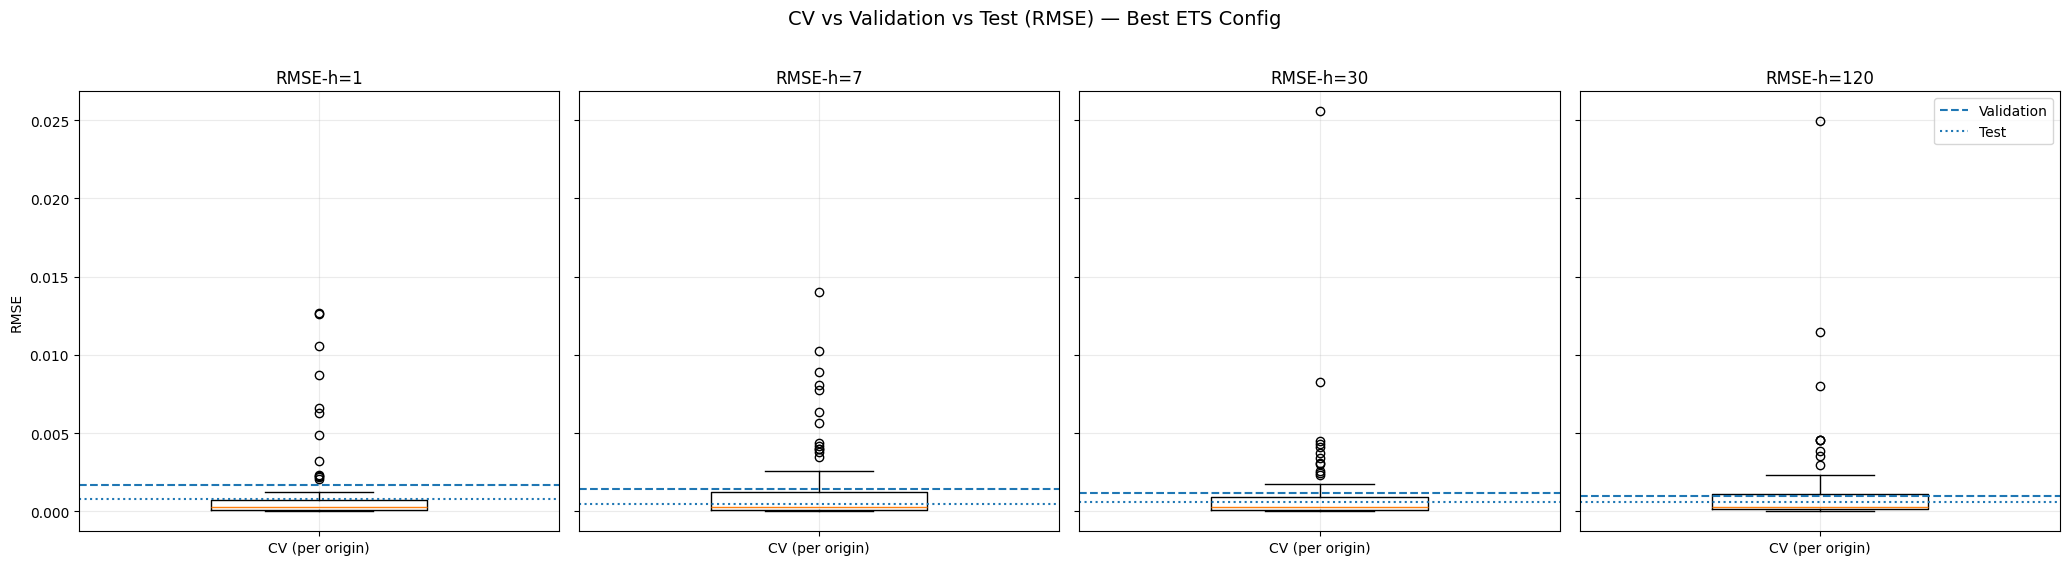

In [130]:
# Boxplots comparing CV distribution (per origin) vs Validation and Test RMSE for the selected ETS model across multiple horizons.
def match_col(df: pd.DataFrame, col: str, value):
    """Match df[col] to value, treating None as NaN."""
    if value is None:
        return df[col].isna()
    return df[col].eq(value)


def plot_ets_cv_val_test_boxplots_multi(results_train: dict, results_validation: dict, results_test: dict, horizons: tuple[int, ...] = (1, 7, 30, 120)):
    """
    Plot CV distribution (per origin) vs Validation and Test RMSE for multiple horizons
    in a single figure with shared y-axis.
    """

    df_all = results_train["df_all_train"].copy()
    best_cfg = results_validation["best_config"]

    # Filter CV rows for the selected best config (ETS)
    mask = (match_col(df_all, "trend", best_cfg.trend) &
            match_col(df_all, "seasonal", best_cfg.seasonal) &
            df_all["damped"].eq(best_cfg.damped) &
            match_col(df_all, "seasonal_periods", best_cfg.seasonal_periods))

    df_cv_best = df_all.loc[mask].copy()

    if df_cv_best.empty:
        available = df_all[["trend", "seasonal", "damped", "seasonal_periods"]].drop_duplicates()
        raise ValueError("No CV rows found for best ETS config in df_all_train.\n"
                         f"Best cfg: trend={best_cfg.trend}, seasonal={best_cfg.seasonal}, damped={best_cfg.damped}, seasonal_periods={best_cfg.seasonal_periods}\n"
                         f"Available configs:\n{available}")

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    # Prepare plot
    fig, axes = plt.subplots(1, len(horizons), figsize=(5.2 * len(horizons), 5.5), sharey=True)

    if len(horizons) == 1:
        axes = [axes]

    for ax, h in zip(axes, horizons):
        col = f"RMSE-h={h}"

        if col not in df_cv_best.columns:
            raise ValueError(f"{col} not found in CV results.")

        cv_values = df_cv_best[col].dropna().values
        val_value = float(results_validation["best_row"].get(col, np.nan))
        test_value = float(results_test["test_results"].iloc[0].get(col, np.nan))

        ax.boxplot(cv_values, vert=True, widths=0.45)
        ax.axhline(val_value, linestyle="--", label="Validation")
        ax.axhline(test_value, linestyle=":", label="Test")

        ax.set_title(f"RMSE-h={h}")
        ax.set_xticks([1])
        ax.set_xticklabels(["CV (per origin)"])
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("RMSE")
    axes[-1].legend(loc="upper right")

    fig.suptitle("CV vs Validation vs Test (RMSE) — Best ETS Config", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_ets_cv_val_test_boxplots_multi(results_train=results_train,
                                    results_validation=results_validation,
                                    results_test=results_test,
                                    horizons=(1, 7, 30, 120))

In [131]:
# Calculate generalization gaps in percentage terms for each horizon and the average score.
def ets_generalization_gaps_percent(results_train: dict, results_validation: dict, results_test: dict):

    best_cfg = results_validation["best_config"]
    df_train = results_train["summary_train"].copy()

    def match_col(df: pd.DataFrame, col: str, value):
        if value is None:
            return df[col].isna()
        return df[col].eq(value)

    mask = (match_col(df_train, "trend", best_cfg.trend) &
            match_col(df_train, "seasonal", best_cfg.seasonal) &
            df_train["damped"].eq(best_cfg.damped) &
            match_col(df_train, "seasonal_periods", best_cfg.seasonal_periods))

    df_train_best = df_train.loc[mask]

    if df_train_best.empty:
        available = df_train[["trend", "seasonal", "damped", "seasonal_periods"]].drop_duplicates()
        raise ValueError("Best validation ETS config not found in results_train['summary_train'].\n"
                         f"Best cfg: trend={best_cfg.trend}, seasonal={best_cfg.seasonal}, damped={best_cfg.damped}, seasonal_periods={best_cfg.seasonal_periods}\n"
                         f"Available configs:\n{available}")

    train_row = df_train_best.iloc[0]
    val_row = results_validation["best_row"]
    test_row = results_test["test_results"].iloc[0]

    rmse_cols = sorted([c for c in test_row.index if str(c).startswith("RMSE-h=")], key=lambda x: int(str(x).split("=")[1]))

    metric_cols = rmse_cols + (["score_rmse_mean"] if "score_rmse_mean" in test_row.index else [])

    def pct_gap(a, b, eps: float = 1e-8):
        b = float(b)
        if abs(b) < eps:
            return np.nan
        return (float(a) - b) / b * 100.0

    rows = []

    for m in metric_cols:
        rows.append({"Metric": m,
                     "Val_vs_Train_%": pct_gap(val_row[m], train_row[m]),
                     "Test_vs_Train_%": pct_gap(test_row[m], train_row[m]),
                     "Test_vs_Val_%": pct_gap(test_row[m], val_row[m])})

    df = pd.DataFrame(rows)
    df = df.set_index("Metric").T

    return df

In [132]:
# Calculate and display generalization gaps in percentage terms
gap_df = ets_generalization_gaps_percent(results_train=results_train,
                                         results_validation=results_validation,
                                         results_test=results_test)

display_table(gap_df, "Generalization Gaps (%)")


Generalization Gaps (%)
╒═════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════════╕
│                 │   RMSE-h=1   │   RMSE-h=7   │  RMSE-h=15   │  RMSE-h=30   │  RMSE-h=120  │   score_rmse_mean │
╞═════════════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╪═══════════════════╡
│ Val_vs_Train_%  │ 36.37234748  │  0.74156070  │ -66.18910107 │ -0.04896210  │ -22.81984634 │      -27.34118543 │
├─────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────────┤
│ Test_vs_Train_% │ -36.35061859 │ -69.78658307 │ -85.34772456 │ -48.74515487 │ -54.04616894 │      -67.26821928 │
├─────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────────┤
│  Test_vs_Val_%  │ -53.32676852 │ -70.00898465 │ -56.66404649 │ -48.72004713 │ -40.45900548 │      -54.95139728 │
╘═════════════════╧══════════════╧══════════════╧══════

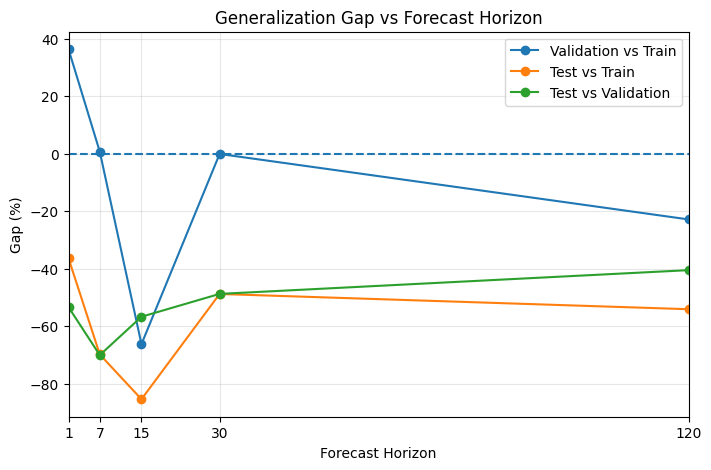

In [133]:
# Plot percentage generalization gaps vs forecast horizon.
df = gap_df.copy()

# Extract horizons from column names
horizons = [int(c.split("=")[1]) for c in df.columns if c.startswith("RMSE-h=")]

# Sort horizons
horizons = sorted(horizons)

val_train = [df.loc["Val_vs_Train_%", f"RMSE-h={h}"] for h in horizons]
test_train = [df.loc["Test_vs_Train_%", f"RMSE-h={h}"] for h in horizons]
test_val = [df.loc["Test_vs_Val_%", f"RMSE-h={h}"] for h in horizons]

plt.figure(figsize=(8,5))

plt.plot(horizons, val_train, marker="o", label="Validation vs Train")
plt.plot(horizons, test_train, marker="o", label="Test vs Train")
plt.plot(horizons, test_val, marker="o", label="Test vs Validation")

plt.axhline(0, linestyle="--")
plt.xticks(horizons)
plt.xlim(min(horizons), max(horizons))

plt.xlabel("Forecast Horizon")
plt.ylabel("Gap (%)")
plt.title("Generalization Gap vs Forecast Horizon")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [134]:
# teste de manwitney

---

# Comparação com o modelo Naive

In [135]:
# Naive forecast implementation
def naive_forecast(y_train: pd.Series, h: int):
    """
    Naive forecast (lag-1 / persistence):
    y_hat(t+h) = y(t)
    for all h >= 1
    """

    if len(y_train) < 1:
        raise ValueError("Training series must contain at least one observation.")

    if h < 1:
        raise ValueError("Forecast horizon h must be >= 1.")

    last_value = float(y_train.iloc[-1])

    forecast = np.repeat(last_value, h)

    return forecast.astype(float)


# Seasonal naive forecast implementation
def seasonal_naive_forecast(y_train: pd.Series, h: int, m: int):
    """
    Seasonal naive forecast:
    y_hat(t+h) = y(t+h-m)
    """

    if h < 1:
        raise ValueError("Forecast horizon h must be >= 1.")

    if m is None or m < 2:
        raise ValueError("Seasonal period m must be >= 2 for seasonal naive forecast.")

    if len(y_train) < m:
        raise ValueError("Training series too short for seasonal naive.")

    last_season = y_train.iloc[-m:].values

    reps = int(np.ceil(h / m))
    forecast = np.tile(last_season, reps)[:h]

    return forecast.astype(float)

In [136]:
# Evaluate naive / seasonal naive on a single validation/test origin
def naive_evaluate_single_origin(y_train: pd.Series, y_eval: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None, metric: str = "RMSE",
                                 scale_transformer: Optional[PowerTransformer] = None):
    """
    Evaluate naive or seasonal naive on a single forecast origin.

    Notes
    -----
    - y_train is the information available before the origin.
    - y_eval contains the future observations after the origin.
    - Forecasts and observations are inverted to the original volatility-proxy scale.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_eval) < hmax:
        raise ValueError(f"Evaluation set too short for hmax={hmax}. len(y_eval)={len(y_eval)}")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if m is None:
        y_hat = naive_forecast(y_train=y_train, h=hmax)
        row = {"model": "naive", "variant": "naive", "m": None}

    else:
        y_hat = seasonal_naive_forecast(y_train=y_train, h=hmax, m=m)
        row = {"model": "naive", "variant": f"seasonal_naive(m={m})", "m": m}

    y_hat = np.asarray(y_hat, dtype=float)
    y_eval_hmax = y_eval.iloc[:hmax].values.astype(float)

    # Convert forecasts to original volatility-proxy scale
    y_hat_original = inverse_variance_transformation(values=y_hat, reference_series=y_train, yeo_johnson_transformer=scale_transformer,
                                                     clip_negative=True)

    # Convert observed future values to original volatility-proxy scale
    y_eval_hmax_original = inverse_variance_transformation(values=y_eval_hmax, reference_series=y_eval, yeo_johnson_transformer=scale_transformer,
                                                           clip_negative=True)

    rmse_list = []
    mape_list = []
    smape_list = []
    qlike_list = []

    forecast_rows = []

    for h in horizons:
        y_true = np.asarray([y_eval_hmax_original[h - 1]])
        y_pred = np.asarray([y_hat_original[h - 1]])

        row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
        row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
        row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

        rmse_list.append(row[f"RMSE-h={h}"])
        mape_list.append(row[f"MAPE-h={h}"])
        smape_list.append(row[f"SMAPE-h={h}"])
        qlike_list.append(row[f"QLIKE-h={h}"])

        y_true_h = float(y_eval_hmax_original[h - 1])
        y_pred_h = float(y_hat_original[h - 1])

        forecast_rows.append({"model": "naive",
                              "variant": row["variant"],
                              "m": m,
                              "horizon": int(h),
                              "y_true_vol_proxy": y_true_h,
                              "forecast": y_pred_h,
                              "residual": y_true_h - y_pred_h})

    row["score_rmse_mean"] = float(np.nanmean(rmse_list))
    row["score_mape_mean"] = float(np.nanmean(mape_list))
    row["score_smape_mean"] = float(np.nanmean(smape_list))
    row["score_qlike_mean"] = float(np.nanmean(qlike_list))

    if metric == "RMSE":
        row["score_selected"] = row["score_rmse_mean"]
    elif metric == "MAPE":
        row["score_selected"] = row["score_mape_mean"]
    elif metric == "SMAPE":
        row["score_selected"] = row["score_smape_mean"]
    elif metric == "QLIKE":
        row["score_selected"] = row["score_qlike_mean"]

    row["valid"] = True

    df_forecasts = pd.DataFrame(forecast_rows)

    return row, df_forecasts

In [137]:
# Evaluate naive / seasonal naive using rolling/expanding origins
def naive_evaluate_rolling(y_train: pd.Series, y_eval: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None, metric: str = "RMSE",
                           mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                           scale_transformer: Optional[PowerTransformer] = None, stage_name: str = "evaluation"):
    """
    Evaluate naive or seasonal naive using rolling/expanding origins.

    Parameters
    ----------
    y_train (pd.Series): Historical series before the evaluation period.

    y_eval (pd.Series): Validation or test series.

    horizons (tuple[int, ...]): Forecast horizons to evaluate.

    m (Optional[int]): Seasonal period for seasonal naive. If None, use non-seasonal naive.

    metric (str): Metric to use for scoring and model selection ("RMSE", "MAPE", "SMAPE", "QLIKE").

    mode (BacktestMode): "rolling" or "expanding" origins.

    step (int): Step size for rolling origins.

    window (Optional[int]): Window size for rolling origins.

    scale_transformer (Optional[PowerTransformer]): Transformer for variance stabilization.

    stage_name (str): Name used only for progress display.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    blocks = generate_evaluation_backtest_blocks(y_train=y_train, y_val=y_eval, horizons=horizons, mode=mode, window=window, step=step)

    y_full = pd.concat([y_train, y_eval]).copy()

    rows = []
    forecast_frames = []

    for b in tqdm(blocks, desc=f"Naive {stage_name} - origins", unit="origin"):

        try:
            origin_date = y_full.index[b.origin]
        except Exception:
            origin_date = None

        try:
            out, df_forecast = naive_evaluate_single_origin(y_train=b.train,
                                                            y_eval=b.test,
                                                            horizons=horizons,
                                                            m=m,
                                                            metric=metric,
                                                            scale_transformer=scale_transformer)

            if out.get("valid", False):
                out["origin"] = b.origin
                out["origin_date"] = origin_date
                rows.append(out)

                if not df_forecast.empty:
                    df_forecast["origin"] = b.origin
                    df_forecast["origin_date"] = origin_date
                    forecast_frames.append(df_forecast)

        except Exception as e:
            # Keep robust behaviour, but do not stop the full evaluation
            # print(f"Naive failed at origin {b.origin}: {e}")
            continue

    df_by_origin = pd.DataFrame(rows)

    df_forecasts = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_by_origin.empty:
        raise ValueError("No valid naive origins could be evaluated.")

    group_cols = ["model", "variant", "m"]

    rmse_cols = sorted([c for c in df_by_origin.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_by_origin.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_by_origin.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_by_origin.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean",
                                                                      "score_mape_mean",
                                                                      "score_smape_mean",
                                                                      "score_qlike_mean",
                                                                      "score_selected"])

    metric_cols = [c for c in metric_cols if c in df_by_origin.columns]

    df_results = (df_by_origin.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    id_cols = ["model", "variant", "m"]
    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols
    ordered_cols = [c for c in ordered_cols if c in df_results.columns]

    df_results = df_results[ordered_cols].copy()

    return {"results": df_results,
            "results_by_origin": df_by_origin,
            "df_forecasts": df_forecasts,
            "blocks_n": len(blocks),
            "hmax": max(horizons),
            "model": "naive",
            "variant": "naive" if m is None else f"seasonal_naive(m={m})",
            "m": m}

In [138]:
# Caching mechanism for Naive rolling/expanding test results
def run_or_load_naive_test(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None,
                           metric: str = "RMSE", mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                           scale_transformer: Optional[PowerTransformer] = None):
    """
    Run or load final Naive test evaluation using rolling/expanding test origins.

    Cache files
    -----------
    - meta.json
    - test_results.parquet
    - test_results_by_origin.parquet
    - forecasts.parquet

    Notes
    -----
    - Uses y_dev = y_train + y_val as the historical information before the test period.
    - Forecasts and observations are stored on the original volatility-proxy scale.
    """

    def series_signature(y: pd.Series):
        """
        Create a simple signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    test_file = cache_path / "test_results.parquet"
    test_by_origin_file = cache_path / "test_results_by_origin.parquet"
    forecasts_file = cache_path / "forecasts.parquet"

    expected_meta = {"horizons": list(sorted(set(int(h) for h in horizons))),
                     "mode": mode,
                     "step": step,
                     "window": int(window) if window is not None else None,
                     "m": int(m) if m is not None else None,
                     "metric": metric,
                     "model": "naive",
                     "variant": "naive" if m is None else f"seasonal_naive(m={m})",
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "test_type": "rolling_expanding_origins",
                     "y_train_signature": series_signature(y_train),
                     "y_train_length": len(y_train),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),
                     "y_val_signature": series_signature(y_val),
                     "y_val_length": len(y_val),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),
                     "y_test_signature": series_signature(y_test),
                     "y_test_length": len(y_test),
                     "y_test_start": str(y_test.index.min()),
                     "y_test_end": str(y_test.index.max())}

    required_files_exist = (meta_file.exists() and test_file.exists() and test_by_origin_file.exists() and forecasts_file.exists())

    # Load only if cache exists and metadata matches current input
    if required_files_exist:
        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        cache_is_valid = (meta.get("horizons") == expected_meta["horizons"]
                          and meta.get("mode") == expected_meta["mode"]
                          and meta.get("step") == expected_meta["step"]
                          and meta.get("window") == expected_meta["window"]
                          and meta.get("m") == expected_meta["m"]
                          and meta.get("metric") == expected_meta["metric"]
                          and meta.get("model") == expected_meta["model"]
                          and meta.get("variant") == expected_meta["variant"]
                          and meta.get("stored_forecasts") == expected_meta["stored_forecasts"]
                          and meta.get("forecast_scale") == expected_meta["forecast_scale"]
                          and meta.get("test_type") == expected_meta["test_type"]
                          and meta.get("y_train_signature") == expected_meta["y_train_signature"]
                          and meta.get("y_train_length") == expected_meta["y_train_length"]
                          and meta.get("y_train_start") == expected_meta["y_train_start"]
                          and meta.get("y_train_end") == expected_meta["y_train_end"]
                          and meta.get("y_val_signature") == expected_meta["y_val_signature"]
                          and meta.get("y_val_length") == expected_meta["y_val_length"]
                          and meta.get("y_val_start") == expected_meta["y_val_start"]
                          and meta.get("y_val_end") == expected_meta["y_val_end"]
                          and meta.get("y_test_signature") == expected_meta["y_test_signature"]
                          and meta.get("y_test_length") == expected_meta["y_test_length"]
                          and meta.get("y_test_start") == expected_meta["y_test_start"]
                          and meta.get("y_test_end") == expected_meta["y_test_end"])

        if cache_is_valid:
            df_test = pd.read_parquet(test_file)
            df_test_by_origin = pd.read_parquet(test_by_origin_file)
            df_forecasts_test = pd.read_parquet(forecasts_file)

            return {"results": df_test,
                    "results_by_origin": df_test_by_origin,
                    "df_forecasts": df_forecasts_test,
                    "blocks_n": meta.get("blocks_n"),
                    "hmax": meta.get("hmax"),
                    "model": "naive",
                    "variant": expected_meta["variant"],
                    "m": m,
                    "forecast": df_forecasts_test["forecast"].to_numpy(dtype=float) if "forecast" in df_forecasts_test.columns else np.array([]),
                    "y_true": df_forecasts_test["y_true_vol_proxy"].to_numpy(dtype=float) if "y_true_vol_proxy" in df_forecasts_test.columns else np.array([]),
                    "meta": meta}

        print("Warning: cache metadata does not match current Naive test input. Recomputing Naive test.")

    # Otherwise run rolling/expanding test evaluation
    y_dev = pd.concat([y_train, y_val]).copy()

    out = naive_evaluate_rolling(y_train=y_dev,
                                 y_eval=y_test,
                                 horizons=horizons,
                                 m=m,
                                 metric=metric,
                                 mode=mode,
                                 step=step,
                                 window=window,
                                 scale_transformer=scale_transformer,
                                 stage_name="test")

    meta = {**expected_meta,
            "hmax": int(out.get("hmax", max(horizons))),
            "y_dev_len": int(len(y_dev)),
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["results"].to_parquet(test_file, index=False)
    out["results_by_origin"].to_parquet(test_by_origin_file, index=False)
    out["df_forecasts"].to_parquet(forecasts_file, index=False)

    out["meta"] = meta

    return out

In [139]:
# Evaluate naive benchmark on test set using rolling/expanding origins
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_ETS_results"

cache_name_naive_test = f"Tese_Bitcoin_Naive_test_{mode}_step{step}_h{max(horizons)}_pkl"

y_dev = pd.concat([y_train, y_val]).copy()

results_naive_test = run_or_load_naive_test(cache_dir=cache_dir,
                                            cache_name=cache_name_naive_test,
                                            y_train=y_train,
                                            y_val=y_val,
                                            y_test=y_test,
                                            horizons=horizons,
                                            m=None,
                                            metric="RMSE",
                                            mode=mode,
                                            step=step,
                                            window=None,
                                            scale_transformer=scale_transformer)

df_naive_test = results_naive_test["results"].copy()

display_table(df_naive_test, "Naive model (rolling test):")

Naive test - origins: 100%|██████████| 68/68 [00:00<00:00, 320.72origin/s]


Naive model (rolling test):
╒════╤═════════╤═══════════╤═════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤══════════════════╤════════════════╤═══════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  model  │  variant  │  m  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7     │   MAPE-h=15    │   MAPE-h=30   │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_selected │
╞════╪═════════╪═══════════╪═════╪════════════╪════════════╪═════════════╪═════════

In [140]:
# Compare ETS vs Naive on test set
df_ets_test = results_test["test_results"].copy()

# Use the rolling/expanding naive test results
df_naive_results = results_naive_test["results"].copy()

# Add model identifiers before concatenating
df_ets_test["Model"] = "ETS"
df_naive_results["Model"] = "Naive"

# Concatenate results
df_compare_ets = pd.concat([df_ets_test, df_naive_results], ignore_index=True)

# Set model name as index
df_compare_ets = df_compare_ets.set_index("Model")

# Remove columns that are not useful for final presentation
cols_to_drop = ["model", "variant", "score_selected"]
df_compare_ets = df_compare_ets.drop(columns=cols_to_drop, errors="ignore")

# Convert ETS seasonal period to integer display where possible
if "m" in df_compare_ets.columns:
    df_compare_ets["m"] = df_compare_ets["m"].astype("Int64")

# Replace missing ETS-specific parameters in Naive row with "-"
for col in ["trend", "seasonal", "damped", "m"]:
    if col in df_compare_ets.columns:
        df_compare_ets[col] = (df_compare_ets[col].astype(str).replace("<NA>", "-").replace("nan", "-").replace("None", "-"))

display_table(df_compare_ets, "ETS vs Naive (test)")


ETS vs Naive (test)
╒═════════╤═════════╤════════════╤══════════╤════════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤══════════════════╤════════════════╤═══════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤═════╕
│  Model  │  trend  │  seasonal  │  damped  │  seasonal_periods  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7     │   MAPE-h=15    │   MAPE-h=30   │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │ m   │
╞═════════╪═════════╪════════════╪══════════╪════════

In [ ]:
# Diebold-Mariano test: ETS vs Naive by forecast horizon
def diebold_mariano_test(loss_1: np.ndarray, loss_2: np.ndarray, horizon: int, step: int = 1):
    """
    Perform the Diebold-Mariano test for equal predictive accuracy.
    The loss differential is defined as:
        d_t = loss_1_t - loss_2_t

    Therefore:
    - a negative statistic favours model 1;
    - a positive statistic favours model 2.

    A Newey-West long-run variance estimator is used to account for dependence caused by overlapping multi-step forecasts.
    The Harvey-Leybourne-Newbold finite-sample correction is also applied.

    Parameters
    ----------
    loss_1 (np.ndarray): Loss values for model 1.

    loss_2 (np.ndarray): Loss values for model 2.

    horizon (int): Forecast horizon.

    step (int, default=1): Step between forecast origins.

    Returns
    -------
    dm_statistic (float): Diebold-Mariano test statistic.

    p_value (float): Two-sided p-value.

    mean_loss_difference (float): Mean of loss_1 - loss_2.

    n_obs (int): Number of paired forecast errors.

    hac_lag (int): Lag used in the long-run variance estimator.
    """

    loss_1 = np.asarray(loss_1, dtype=float)
    loss_2 = np.asarray(loss_2, dtype=float)

    valid = np.isfinite(loss_1) & np.isfinite(loss_2)

    loss_1 = loss_1[valid]
    loss_2 = loss_2[valid]

    if len(loss_1) != len(loss_2):
        raise ValueError("The loss sequences must have the same length.")

    n_obs = len(loss_1)

    if n_obs < 5:
        return np.nan, np.nan, np.nan, n_obs, np.nan

    loss_difference = loss_1 - loss_2
    mean_loss_difference = float(np.mean(loss_difference))

    # Effective overlap when forecast origins advance by more than one period
    effective_horizon = max(1, int(ceil(horizon / step)))
    hac_lag = min(effective_horizon - 1, n_obs - 1)

    centred = loss_difference - mean_loss_difference

    # Lag-zero autocovariance
    long_run_variance = np.dot(centred, centred) / n_obs

    # Newey-West autocovariances with Bartlett weights
    for lag in range(1, hac_lag + 1):
        autocovariance = (np.dot(centred[lag:], centred[:-lag]) / n_obs)
        weight = 1.0 - lag / (hac_lag + 1.0)
        long_run_variance += 2.0 * weight * autocovariance

    variance_of_mean = long_run_variance / n_obs

    if not np.isfinite(variance_of_mean) or variance_of_mean <= 0:
        return (np.nan, np.nan, mean_loss_difference, n_obs, hac_lag)

    dm_statistic = (mean_loss_difference / np.sqrt(variance_of_mean))

    # Harvey-Leybourne-Newbold finite-sample correction
    correction = (n_obs + 1 - 2 * effective_horizon + (effective_horizon * (effective_horizon - 1) / n_obs)) / n_obs

    if correction > 0:
        dm_statistic *= np.sqrt(correction)

    p_value = 2.0 * (1.0 - t.cdf(abs(dm_statistic), df=n_obs - 1))

    return (float(dm_statistic), float(p_value), mean_loss_difference, int(n_obs), int(hac_lag))


def compare_ets_vs_naive_dm(results_ets: dict, results_naive: dict, horizons: Iterable[int], step: int = 1):
    """
    Compare ETS and Naive forecasts using horizon-specific Diebold-Mariano tests with squared-error loss.

    Parameters
    ----------
    results_ets (dict): Output returned by run_or_load_ets_test.

    results_naive (dict): Output returned by run_or_load_naive_test.

    horizons (Iterable[int]): Forecast horizons to compare.

    step (int, default=1): Step between forecast origins.

    Returns
    -------
    df_dm (pd.DataFrame): Horizon-specific Diebold-Mariano results.
    """

    df_ets = results_ets["df_forecasts_test"].copy()
    df_naive = results_naive["df_forecasts"].copy()

    required_columns = {"origin", "horizon", "y_true_vol_proxy", "forecast"}

    missing_ets = required_columns - set(df_ets.columns)
    missing_naive = required_columns - set(df_naive.columns)

    if missing_ets:
        raise KeyError(f"Missing ETS forecast columns: {sorted(missing_ets)}")

    if missing_naive:
        raise KeyError(f"Missing Naive forecast columns: {sorted(missing_naive)}")

    results = []

    for horizon in sorted(set(int(h) for h in horizons)):

        ets_h = (df_ets.loc[df_ets["horizon"] == horizon, ["origin", "y_true_vol_proxy", "forecast"]]
                 .rename(columns={"y_true_vol_proxy": "y_true_ets", "forecast": "forecast_ets"}))
        naive_h = (df_naive.loc[df_naive["horizon"] == horizon, ["origin", "y_true_vol_proxy", "forecast"]]
                   .rename(columns={"y_true_vol_proxy": "y_true_naive", "forecast": "forecast_naive"}))

        paired = ets_h.merge(naive_h, on="origin", how="inner", validate="one_to_one")

        if paired.empty:
            results.append({"Horizon": horizon,
                            "N": 0,
                            "Mean squared loss ETS": np.nan,
                            "Mean squared loss Naive": np.nan,
                            "DM statistic": np.nan,
                            "p-value": np.nan,
                            "Preferred model": "Unavailable"})
            continue

        # Confirm that both models are evaluated against the same observations
        if not np.allclose(paired["y_true_ets"], paired["y_true_naive"], equal_nan=True):
            raise ValueError(f"Observed values do not match at horizon h={horizon}.")

        loss_ets = (paired["y_true_ets"].to_numpy(dtype=float) - paired["forecast_ets"].to_numpy(dtype=float)) ** 2
        loss_naive = (paired["y_true_naive"].to_numpy(dtype=float) - paired["forecast_naive"].to_numpy(dtype=float)) ** 2

        (dm_statistic, p_value, mean_loss_difference, n_obs, hac_lag) = diebold_mariano_test(loss_1=loss_ets,
                                                                                             loss_2=loss_naive,
                                                                                             horizon=horizon,
                                                                                             step=step)

        if mean_loss_difference < 0:
            preferred_model = "ETS"
        elif mean_loss_difference > 0:
            preferred_model = "Naive"
        else:
            preferred_model = "Tie"

        results.append({"Horizon": horizon,
                        "N": n_obs,
                        "Mean squared loss ETS": float(np.mean(loss_ets)),
                        "Mean squared loss Naive": float(np.mean(loss_naive)),
                        "DM statistic": dm_statistic,
                        "p-value": p_value,
                        "HAC lag": hac_lag,
                        "Preferred model": preferred_model})

    df_dm = pd.DataFrame(results)

    # Holm correction for the five horizon-specific comparisons
    valid_p_values = df_dm["p-value"].notna()

    df_dm["Adjusted p-value"] = np.nan
    df_dm["Significant at 5%"] = False

    if valid_p_values.any():
        reject, adjusted_p_values, _, _ = multipletests(df_dm.loc[valid_p_values, "p-value"], alpha=0.05, method="holm")

        df_dm.loc[valid_p_values, "Adjusted p-value"] = adjusted_p_values
        df_dm.loc[valid_p_values, "Significant at 5%"] = reject

    return df_dm


# Run horizon-specific Diebold-Mariano tests
print(step)
df_dm_ets_vs_naive = compare_ets_vs_naive_dm(results_ets=results_test,
                                             results_naive=results_naive_test,
                                             horizons=horizons,
                                             step=step)

display_table(df_dm_ets_vs_naive.set_index("Horizon"), "Diebold-Mariano test: ETS vs Naive")

---

# Análise de Resíduos

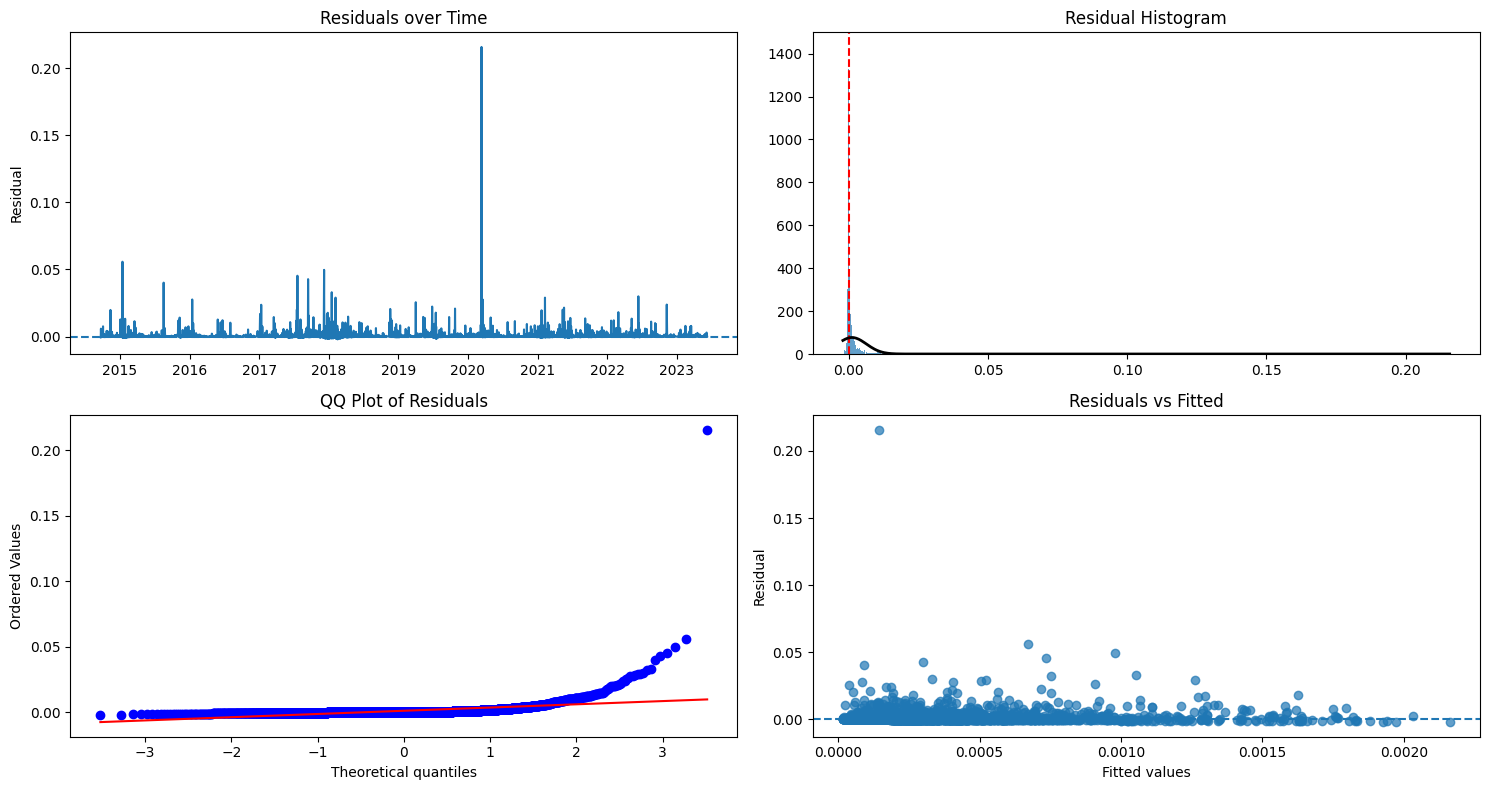

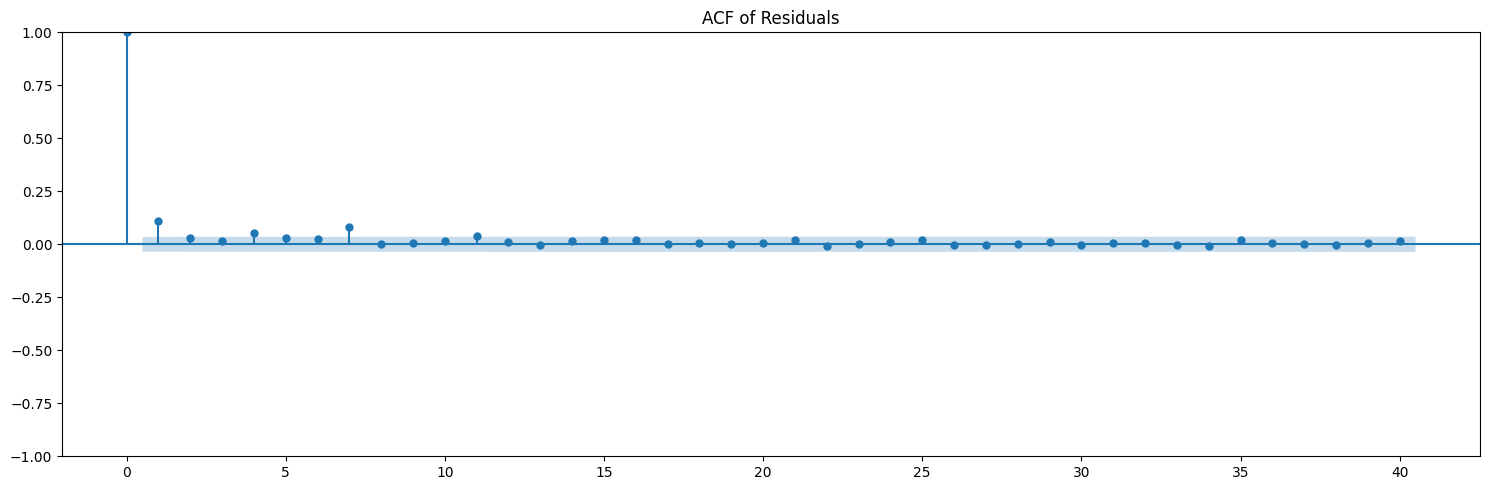


Residual Diagnostics - Final ETS Model - Original Scale
╒════╤════════════════════════════╤══════════════╕
│    │           Metric           │        Value │
╞════╪════════════════════════════╪══════════════╡
│ 0  │            Mean            │   0.00113807 │
├────┼────────────────────────────┼──────────────┤
│ 1  │           Median           │   0.00002442 │
├────┼────────────────────────────┼──────────────┤
│ 2  │            Std             │   0.00518403 │
├────┼────────────────────────────┼──────────────┤
│ 3  │          Skewness          │  24.40145177 │
├────┼────────────────────────────┼──────────────┤
│ 4  │          Kurtosis          │ 936.95535480 │
├────┼────────────────────────────┼──────────────┤
│ 5  │        KS Statistic        │   0.33683687 │
├────┼────────────────────────────┼──────────────┤
│ 6  │         KS p-value         │   0.00000000 │
├────┼────────────────────────────┼──────────────┤
│ 7  │ Ljung-Box p-value (lag=20) │   0.00000000 │
╘════╧═══════════════════

In [141]:
# Final ETS model fitting and residual diagnostics
def fit_final_ets_model(y_train: pd.Series, y_val: pd.Series, cfg: ETSConfig, scale_transformer: Optional[PowerTransformer] = None, residual_scale: str = "original"):
    """
    Fit the final ETS model on the development set (train + validation).

    Parameters
    ----------
    y_train, y_val (pd.Series): Series in the model estimation scale.

    cfg (ETSConfig): Selected ETS configuration.

    scale_transformer (PowerTransformer, optional): Required only when the series was transformed using Yeo-Johnson.

    residual_scale (str {"original", "model"}):
        - "model": residuals are computed in the model estimation scale.
        - "original": fitted values and observations are inverted to the original
          volatility-proxy scale before residuals are computed.

    Returns
    -------
    dict with:
    - y_dev
    - y_dev_used
    - model
    - fit
    - fitted_values
    - residuals
    - residual_scale
    """

    if residual_scale not in ("original", "model"):
        raise ValueError("residual_scale must be either 'original' or 'model'.")

    y_dev = pd.concat([y_train, y_val]).copy()

    if not is_ets_config_compatible(y_dev, cfg):
        raise ValueError(f"Selected config is not compatible with y_dev: {cfg.to_label()}")

    # ETS model fitting
    model = ExponentialSmoothing(y_dev,
                                 trend=cfg.trend,
                                 damped_trend=cfg.damped if cfg.trend is not None else False,
                                 seasonal=cfg.seasonal,
                                 seasonal_periods=cfg.seasonal_periods,
                                 initialization_method="estimated")

    fit = model.fit()

    # Fitted values and residuals in the model estimation scale
    fitted_model_scale = pd.Series(fit.fittedvalues, index=y_dev.index, name="fitted_model_scale")
    residuals_model_scale = pd.Series(fit.resid, index=y_dev.index, name="residuals_model_scale")

    # Burn-in based on ETS model structure
    burn_in = 0

    if cfg.trend is not None:
        burn_in = max(burn_in, 2)

    if cfg.seasonal is not None and cfg.seasonal_periods is not None:
        burn_in = max(burn_in, int(cfg.seasonal_periods))

    if burn_in > 0:
        y_dev_used = y_dev.iloc[burn_in:].copy()
        fitted_model_scale = fitted_model_scale.iloc[burn_in:].copy()
        residuals_model_scale = residuals_model_scale.iloc[burn_in:].copy()
    else:
        y_dev_used = y_dev.copy()

    if residual_scale == "model":
        fitted_values = fitted_model_scale.rename("fitted")
        residuals = residuals_model_scale.rename("residuals")

    else:
        # Convert observed development series to original volatility-proxy scale
        y_dev_original_values = inverse_variance_transformation(values=y_dev_used.values.astype(float), reference_series=y_dev, yeo_johnson_transformer=scale_transformer,
                                                                clip_negative= True)
        y_dev_original = pd.Series(y_dev_original_values, index=y_dev_used.index, name="observed_original_scale")

        # Convert fitted values to original volatility-proxy scale
        fitted_original_values = inverse_variance_transformation(values=fitted_model_scale.values.astype(float), reference_series=y_dev, yeo_johnson_transformer=scale_transformer,
                                                                 clip_negative= True)

        fitted_values = pd.Series(fitted_original_values, index=fitted_model_scale.index, name="fitted")

        # Residuals on the original scale
        residuals = pd.Series(y_dev_original.loc[fitted_values.index].values - fitted_values.values, index=fitted_values.index, name="residuals")

    return {"y_dev": y_dev,
            "y_dev_used": y_dev_used,
            "model": model,
            "fit": fit,
            "fitted_values": fitted_values,
            "residuals": residuals,
            "residual_scale": residual_scale}

def residual_diagnostics_table(residuals: pd.Series, ljung_box_lags: int = 20):
    """
    Compute a compact residual diagnostics table.
    """
    residuals = residuals.dropna().copy()

    lb = acorr_ljungbox(residuals, lags=[ljung_box_lags], return_df=True)
    ks_stat, ks_pvalue = kstest(residuals.values, "norm", args=(float(residuals.mean()), float(residuals.std(ddof=0))))

    out = pd.DataFrame({"Metric": ["Mean",
                                   "Median",
                                   "Std",
                                   "Skewness",
                                   "Kurtosis",
                                   "KS Statistic",
                                   "KS p-value",
                                   f"Ljung-Box p-value (lag={ljung_box_lags})"],

                        "Value": [float(residuals.mean()),
                                  float(residuals.median()),
                                  float(residuals.std()),
                                  float(residuals.skew()),
                                  float(residuals.kurtosis()),
                                  float(ks_stat),
                                  float(ks_pvalue),
                                  float(lb["lb_pvalue"].iloc[0])]})

    return out

def plot_residual_diagnostics(residuals: pd.Series, fitted_values: pd.Series, acf_lags: int = 40):
    """
    Plot standard residual diagnostics for the final ETS model.
    """
    residuals = residuals.dropna().copy()

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Residual time plot
    axes[0, 0].plot(residuals.index, residuals.values)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals over Time")
    axes[0, 0].set_ylabel("Residual")

    # Histogram with Freedman–Diaconis bins
    n_bins, _ = freedman_diaconis_bins(residuals.values)
    axes[0, 1].hist(residuals.values, bins=n_bins, density=True, alpha=0.7)
    axes[0, 1].axvline(0, linestyle="--", color="red")

    x = np.linspace(residuals.min(), residuals.max(), 500)
    axes[0, 1].plot(x, norm.pdf(x, residuals.mean(), residuals.std()), linewidth=2, color="black")
    axes[0, 1].set_title("Residual Histogram")

    # QQ plot
    stats.probplot(residuals.values, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title("QQ Plot of Residuals")

    # Residuals vs fitted
    axes[1, 1].scatter(fitted_values.loc[residuals.index], residuals.values, alpha=0.7)
    axes[1, 1].axhline(0, linestyle="--")
    axes[1, 1].set_title("Residuals vs Fitted")
    axes[1, 1].set_xlabel("Fitted values")
    axes[1, 1].set_ylabel("Residual")

    plt.tight_layout()
    plt.show()

    # ACF plot in a separate figure
    fig, ax = plt.subplots(figsize=(15, 5))
    plot_acf(residuals, lags=acf_lags, ax=ax)
    ax.set_title("ACF of Residuals")
    plt.tight_layout()
    plt.show()


def run_final_ets_residual_diagnostics(y_train: pd.Series, y_val: pd.Series, cfg: ETSConfig, ljung_box_lags: int = 20, acf_lags: int = 40,
                                       scale_transformer: Optional[PowerTransformer] = None, residual_scale: str = "original"):
    """
    Full residual diagnostics workflow for the final ETS model.
    """

    fit_pack = fit_final_ets_model(y_train=y_train,
                                   y_val=y_val,
                                   cfg=cfg,
                                   scale_transformer=scale_transformer,
                                   residual_scale=residual_scale)

    diag_table = residual_diagnostics_table(residuals=fit_pack["residuals"], ljung_box_lags=ljung_box_lags)

    plot_residual_diagnostics(residuals=fit_pack["residuals"], fitted_values=fit_pack["fitted_values"], acf_lags=acf_lags)

    return {"y_dev": fit_pack["y_dev"],
            "y_dev_used": fit_pack["y_dev_used"],
            "fit": fit_pack["fit"],
            "fitted_values": fit_pack["fitted_values"],
            "residuals": fit_pack["residuals"],
            "residual_scale": fit_pack["residual_scale"],
            "diagnostics_table": diag_table}

best_cfg = results_validation["best_config"]

residual_pack = run_final_ets_residual_diagnostics(y_train=y_train,
                                                     y_val=y_val,
                                                     cfg=best_cfg,
                                                     ljung_box_lags=20,
                                                     acf_lags=40,
                                                     scale_transformer=scale_transformer,
                                                     residual_scale="original")

display_table(residual_pack["diagnostics_table"], "Residual Diagnostics - Final ETS Model - Original Scale")

---

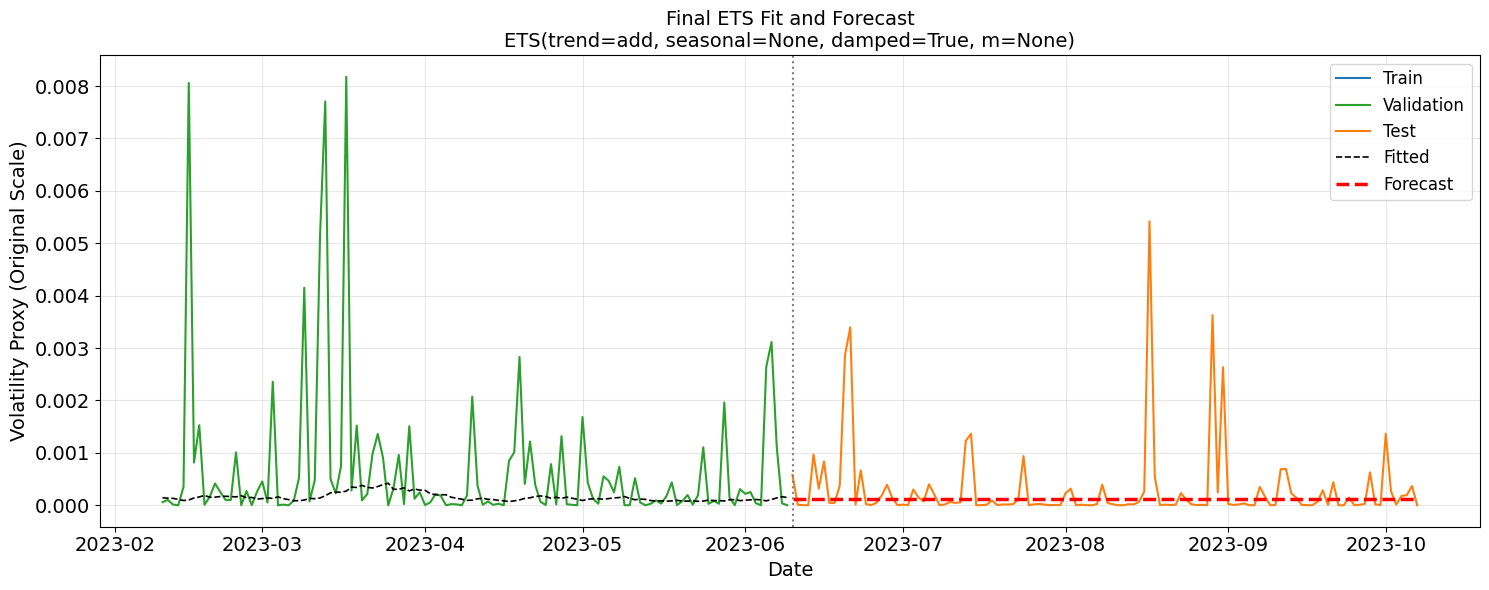

In [142]:
# Fit final ETS model on y_dev and plot fitted values + forecast vs observed (test)
y_dev = pd.concat([y_train, y_val]).copy()
window = 120

model = ExponentialSmoothing(y_dev,
                             trend=best_cfg.trend,
                             damped_trend=best_cfg.damped if best_cfg.trend is not None else False,
                             seasonal=best_cfg.seasonal,
                             seasonal_periods=best_cfg.seasonal_periods,
                             initialization_method="estimated")

fit = model.fit(optimized=True)

fitted = pd.Series(fit.fittedvalues, index=y_dev.index, name="Fitted")
forecast = pd.Series(fit.forecast(steps=window), index=y_test.index[:window], name="Forecast")

# limit plotting window
y_dev_plot = y_dev.iloc[-window:]
fitted_plot = fitted.loc[y_dev_plot.index]

y_train_plot = y_train.loc[y_dev_plot.index.intersection(y_train.index)]
y_val_plot = y_val.loc[y_dev_plot.index.intersection(y_val.index)]

y_test_plot = y_test.iloc[:window]
forecast_plot = forecast.iloc[:window]

# Convert all plotted series to original volatility-proxy scale
y_train_plot_original = pd.Series(inverse_variance_transformation(values=y_train_plot.values, reference_series=y_train, yeo_johnson_transformer=scale_transformer,
                                                                  clip_negative=True), index=y_train_plot.index, name="Train")

y_val_plot_original = pd.Series(inverse_variance_transformation(values=y_val_plot.values, reference_series=y_val, yeo_johnson_transformer=scale_transformer,
                                                                clip_negative=True), index=y_val_plot.index, name="Validation")

y_test_plot_original = pd.Series(inverse_variance_transformation(values=y_test_plot.values, reference_series=y_test, yeo_johnson_transformer=scale_transformer,
                                                                 clip_negative=True), index=y_test_plot.index, name="Test")

fitted_plot_original = pd.Series(inverse_variance_transformation(values=fitted_plot.values, reference_series=y_dev, yeo_johnson_transformer=scale_transformer,
                                                                 clip_negative=True), index=fitted_plot.index, name="Fitted")

forecast_plot_original = pd.Series(inverse_variance_transformation(values=forecast_plot.values, reference_series=y_dev, yeo_johnson_transformer=scale_transformer,
                                                                   clip_negative=True), index=forecast_plot.index, name="Forecast")

plt.figure(figsize=(15, 6))

# Train
plt.plot(y_train_plot_original.index, y_train_plot_original.values, color="tab:blue", label="Train")

# Validation
plt.plot(y_val_plot_original.index, y_val_plot_original.values, color="tab:green", label="Validation")

# Test
plt.plot(y_test_plot_original.index, y_test_plot_original.values, color="tab:orange", label="Test")

# Fitted
plt.plot(fitted_plot_original.index, fitted_plot_original.values, linestyle="--", linewidth=1.2, color="black", label="Fitted")

# Forecast
plt.plot(forecast_plot_original.index, forecast_plot_original.values, linestyle="--", linewidth=2.5, color="red", label="Forecast")

# Split line
plt.axvline(y_test.index[0], linestyle=":", linewidth=1.5, color="grey")

plt.title(f"Final ETS Fit and Forecast\n{best_cfg.to_label()}", fontsize=14)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Volatility Proxy (Original Scale)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

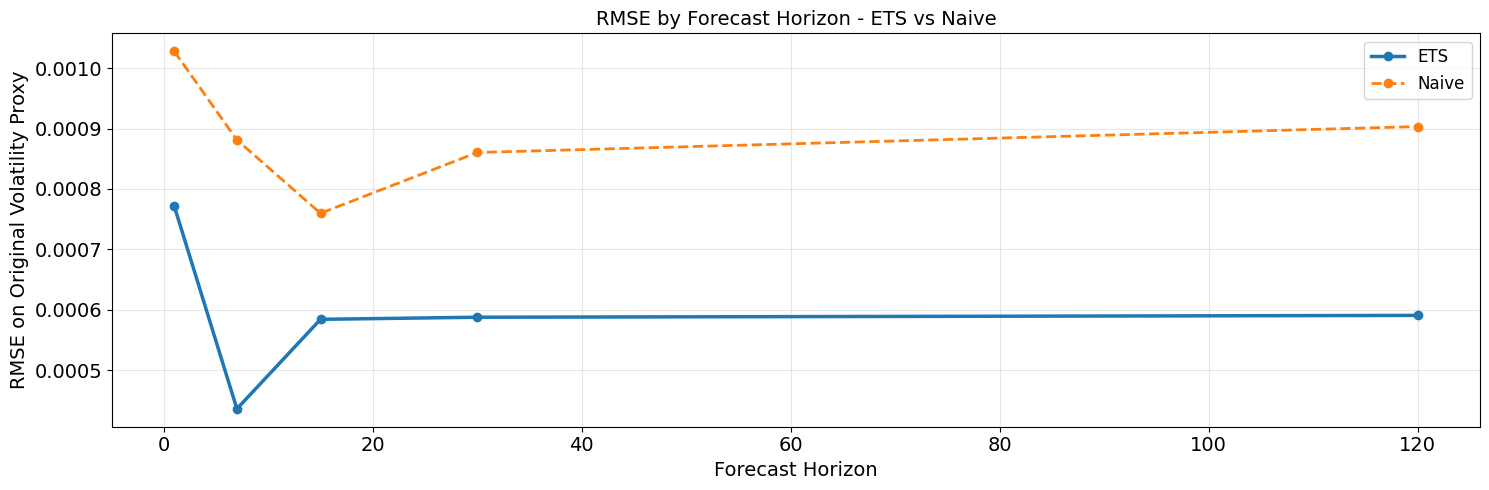

In [143]:
# Compare ETS vs Naive on test set across horizons
def plot_ets_vs_naive_rmse_by_horizon(df_compare: pd.DataFrame):
    """
    Plot RMSE vs horizon comparing ETS and Naive.
    Assumes RMSE values were computed on the original volatility-proxy scale.
    """

    # Ensure index is clean
    df_compare = df_compare.copy()
    df_compare.index = df_compare.index.astype(str).str.strip()

    # Identify RMSE columns
    rmse_cols = sorted([c for c in df_compare.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))

    if len(rmse_cols) == 0:
        raise ValueError("No RMSE-h= columns found in df_compare.")

    if "ETS" not in df_compare.index:
        raise ValueError(f"'ETS' not found in df_compare index. Available index values: {list(df_compare.index)}")

    if "Naive" not in df_compare.index:
        raise ValueError(f"'Naive' not found in df_compare index. Available index values: {list(df_compare.index)}")

    horizons = [int(c.split("=")[1]) for c in rmse_cols]

    # Select rows by index
    ets_row = df_compare.loc["ETS"]
    naive_row = df_compare.loc["Naive"]

    ets_rmse = ets_row[rmse_cols].astype(float).values
    naive_rmse = naive_row[rmse_cols].astype(float).values

    plt.figure(figsize=(15, 5))

    plt.plot(horizons, ets_rmse, marker="o", linewidth=2.5, label="ETS")
    plt.plot(horizons, naive_rmse, marker="o", linestyle="--", linewidth=2, label="Naive")

    plt.title("RMSE by Forecast Horizon - ETS vs Naive", fontsize=14)
    plt.xlabel("Forecast Horizon", fontsize=14)
    plt.ylabel("RMSE on Original Volatility Proxy", fontsize=14)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_ets_vs_naive_rmse_by_horizon(df_compare_ets)

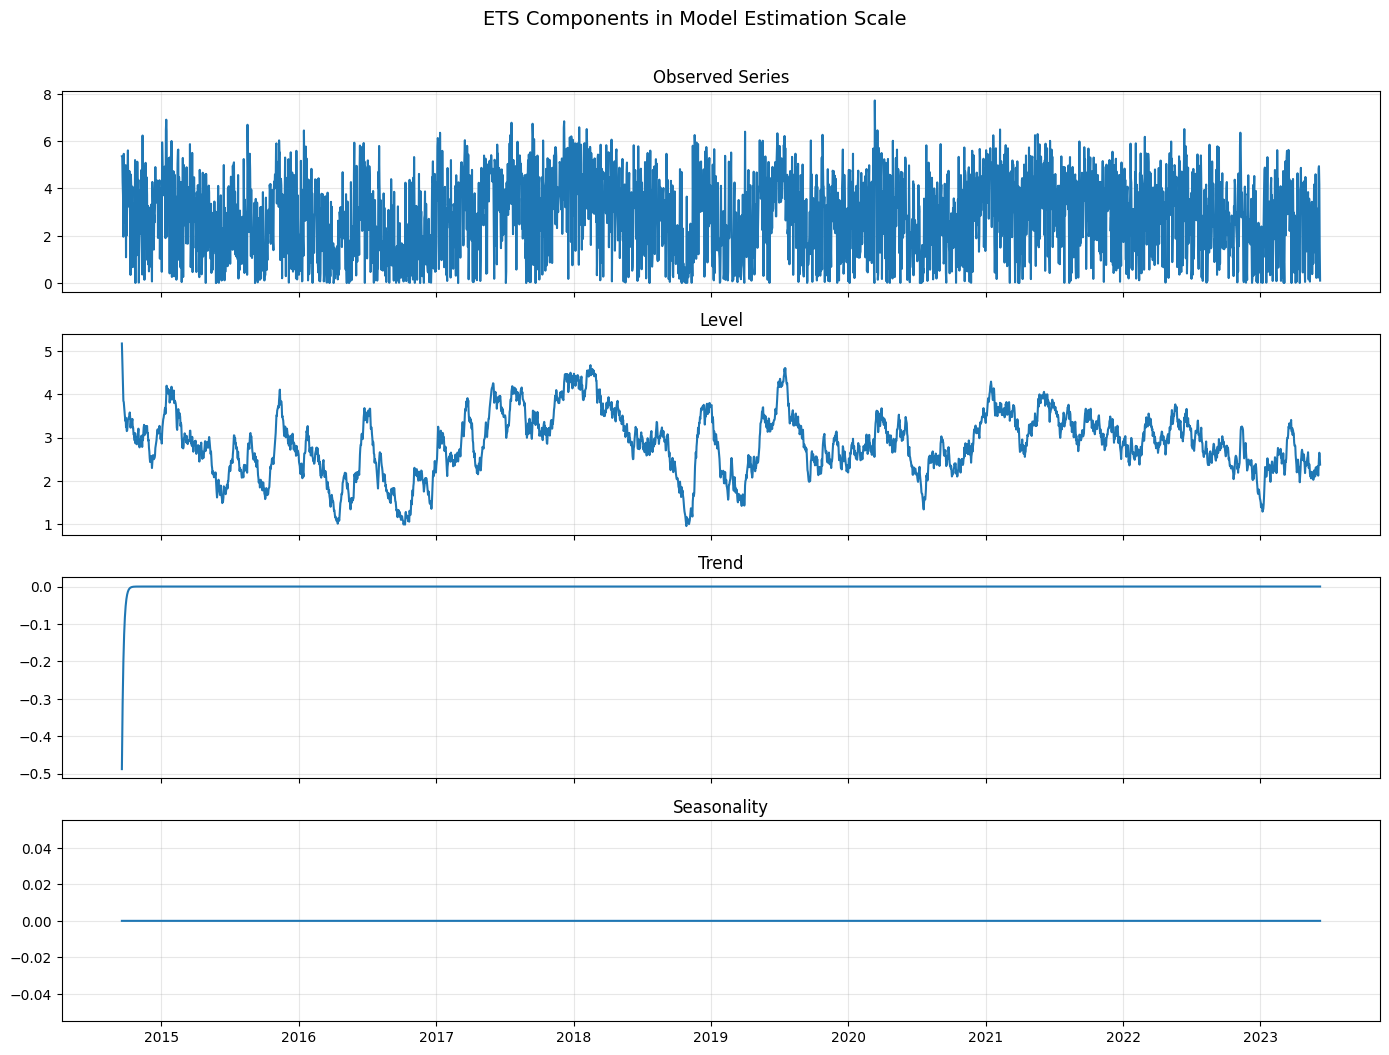

In [144]:
# Plot ETS components: level, trend and seasonal in model estimation scale
fit = residual_pack["fit"]
y_dev = residual_pack["y_dev"]

components = []

# Observed series
components.append(("Observed Series", pd.Series(y_dev.values, index=y_dev.index)))

# Level
if hasattr(fit, "level") and fit.level is not None:
    level = pd.Series(np.asarray(fit.level), index=y_dev.index[:len(fit.level)])
    components.append(("Level", level))

# Trend
if hasattr(fit, "trend") and fit.trend is not None:
    trend = pd.Series(np.asarray(fit.trend), index=y_dev.index[:len(fit.trend)])
    components.append(("Trend", trend))

# Seasonal
if hasattr(fit, "season") and fit.season is not None:
    season = pd.Series(np.asarray(fit.season), index=y_dev.index[:len(fit.season)])
    components.append(("Seasonality", season))

fig, axes = plt.subplots(len(components), 1, figsize=(14, 2.6 * len(components)), sharex=True)

if len(components) == 1:
    axes = [axes]

for ax, (title, series) in zip(axes, components):
    ax.plot(series.index, series.values)
    ax.set_title(title)
    ax.grid(alpha=0.3)

fig.suptitle("ETS Components in Model Estimation Scale", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()